Compute mean connectivity from HCP7T dataset

In [54]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [55]:
tian_scale = 'S2'

lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-prefrontal',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-prefrontal_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [56]:
# Data preparation (all cortical ROIs to keep) 
AUDITORY_ROIS   = ['STGa', 'PP', 'HG', 'PT', 'STGp']
PREFRONTAL_ROIS = ['OFC', 'ACC', 'FMC', 'IFGt', 'IFGo']
CORTEX_ROIS     = AUDITORY_ROIS + PREFRONTAL_ROIS

# Display-only relabeling: the codes above stay unchanged (they must match the
# external atlas LUT / connectivity data); this is applied only when rendering
# text (plot titles, tick labels, annotations).
ROI_DISPLAY_NAMES = {'IFGo': 'ParsOp', 'IFGt': 'ParsTri'}

def _display_label(name):
    if len(name) > 2 and name[:2] in ('L-', 'R-'):
        return name[:2] + ROI_DISPLAY_NAMES.get(name[2:], name[2:])
    return ROI_DISPLAY_NAMES.get(name, name)


In [57]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')


STATS_OUT_DIR = 'stats_exports'
os.makedirs(STATS_OUT_DIR, exist_ok=True)

FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

## Read in participant connectivity matrices

In [ ]:
print(data_dir + 
      '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2-noscaling/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2-noscaling.csv')

In [ ]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         f'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2-noscaling/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2-noscaling.csv'))

# derive participant IDs directly from conn_files (preserves same order)
participants_with_files = sorted(list({os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files}))


In [60]:
print(len(conn_files))

96


In [61]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


          0         1         2         3         4         5         6   \
0   0.830017  0.339446  0.308448  0.142736  0.007415  0.011261  0.003171   
1   0.339446  0.424302  0.044860  0.195487  0.007700  0.020397  0.001533   
2   0.308448  0.044860  1.802076  0.395271  0.009352  0.002107  0.006522   
3   0.142736  0.195487  0.395271  1.048831  0.005213  0.015237  0.005610   
4   0.007415  0.007700  0.009352  0.005213  1.032988  0.311554  0.456820   
5   0.011261  0.020397  0.002107  0.015237  0.311554  0.502170  0.051837   
6   0.003171  0.001533  0.006522  0.005610  0.456820  0.051837  2.083032   
7   0.004873  0.003831  0.005173  0.019199  0.042357  0.192223  1.291996   
8   0.008635  0.411520  0.000759  0.004211  0.000037  0.000082  0.000000   
9   0.064614  0.522822  0.004643  0.007629  0.002060  0.002992  0.000374   
10  0.026864  0.110096  0.003433  0.008276  0.000000  0.000533  0.000109   
11  0.001250  0.029598  0.000199  0.000871  0.000000  0.000000  0.000000   
12  0.006314

In [62]:
num_regions = len(region_list)  # 54
conn_files_54 = [f for f in conn_files
                 if pd.read_csv(f, header=None).shape[0] == num_regions]

num_subjects = len(conn_files_54)
connmats_raw = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []

for sx, matrix_fpath in enumerate(conn_files_54):
    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    connmats_raw[sx,:,:] = sub_df.to_numpy()
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0)

In [ ]:
# --- Per-subject connectome normalisation ----------------------------------
# The connectome CSVs are RAW SIFT2-weighted streamline sums (tck2connectome
# run WITHOUT -scale_invnodevol). Each edge is normalised by:
#   (1) the subject's SIFT2 proportionality coefficient mu -> cross-subject scale
#   (2) the volume of the STRIATAL node only               -> connectivity density
#       C(striatum_i, cortex_j) = mu_s * raw_sum(i, j) / V_striatum(s, i)
# Striatal volumes come from each subject's own T1w/acpc-space parcellation
# (the same image passed to tck2connectome).

striatum_idx = np.array([i for i, r in enumerate(region_list)
                         if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))])

_subatlas_tmpl = ('/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/'
                  'atlas_space-sub/{sub}/sub-{sub}_'
                  f'atlas-custom_subcort-tian{tian_scale}_cort-carpet'
                  '_atlas_warp-standard2acpc_dc_space-T1w.nii.gz')
_mu_tmpl = ('/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/'
            'msmt_csd_nthreads-1/{sub}/'
            'sift2_mu_streamlines_alg-iFOD2_nsl-10mil.txt')

# subject IDs in the same order as connmats_raw (== conn_files_54)
subs_54 = [os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(f))))
           for f in conn_files_54]

mu = np.zeros(num_subjects)
striatal_vol_mm3 = np.zeros((num_subjects, num_regions))   # 0 outside striatum
for sx, sub in enumerate(subs_54):
    mu[sx] = float(np.loadtxt(_mu_tmpl.format(sub=sub)))
    seg_img = nib.load(_subatlas_tmpl.format(sub=sub))
    seg = np.asarray(seg_img.dataobj)
    vox_mm3 = float(np.prod(seg_img.header.get_zooms()[:3]))
    for idx in striatum_idx:
        striatal_vol_mm3[sx, idx] = np.count_nonzero(seg == idx + 1) * vox_mm3

print(f'mu: mean={mu.mean():.4g}  range=[{mu.min():.4g}, {mu.max():.4g}]')
print('striatal volume (mm^3), across-subject mean (SD):')
for idx in striatum_idx:
    v = striatal_vol_mm3[:, idx]
    print(f'  {region_list[idx]:9s} {v.mean():8.1f} ({v.std():6.1f})')

_sv = striatal_vol_mm3[:, striatum_idx]
if (_sv == 0).any():
    print(f'WARNING: {(_sv == 0).sum()} zero striatal volume(s) -> those edges = nan')

# scale the whole matrix by mu; divide the striatal ROWS by their own volume
inv_vol = np.ones((num_subjects, num_regions))
with np.errstate(divide='ignore'):
    inv_vol[:, striatum_idx] = np.where(_sv > 0, 1.0 / _sv, np.nan)

connmats_corrected = connmats_raw * mu[:, None, None] * inv_vol[:, :, None]


In [64]:
connmats = connmats_corrected

In [65]:
np.shape(connmats)

(76, 54, 54)

In [66]:
# check the streamline count matrix (region x subject)
slcounts

array([[2.9932656 , 3.13960188, 3.41811002, ..., 3.2797443 , 2.67507724,
        2.45778141],
       [3.72346354, 4.05369161, 4.39118278, ..., 4.5265553 , 2.59177282,
        3.44055332],
       [3.0203204 , 1.43889476, 1.88506606, ..., 3.03443287, 3.98565649,
        2.10554823],
       ...,
       [6.07374233, 6.60754372, 5.12989893, ..., 6.183805  , 4.74643613,
        5.8193794 ],
       [1.89487069, 3.14537961, 3.07099755, ..., 3.05755014, 2.2295061 ,
        2.52108705],
       [4.15566367, 3.63534291, 3.50998061, ..., 3.88627623, 3.2312409 ,
        3.82539085]])

In [67]:
slcounts[0,:]

array([2.9932656 , 3.13960188, 3.41811002, 4.06843949, 2.66418241,
       2.70541147, 2.64848438, 3.70410158, 2.49805901, 3.99966765,
       3.25666959, 4.5690425 , 2.12417317, 3.22092497, 3.04684179,
       3.95493621, 4.77506281, 0.90540128, 3.01603489, 3.94656244,
       1.91750357, 3.58415546, 2.75201879, 2.80465874, 2.93342102,
       3.34101828, 3.45236009, 4.21083898, 3.6203336 , 3.81162772,
       2.15098174, 3.06014453, 3.16476663, 3.09205826, 1.7043181 ,
       3.047284  , 3.22565096, 2.40021402, 3.2162744 , 3.01228185,
       2.81211847, 2.70279909, 2.3343921 , 2.72354959, 3.09849475,
       2.44154731, 2.63256083, 3.12678451, 3.33854353, 4.58107519,
       2.38302749, 2.65610889, 3.84932627, 3.41907434, 2.39107423,
       2.09346414, 4.31258834, 2.82452864, 3.09731742, 2.85427869,
       2.98054384, 3.25298129, 2.09334252, 2.82554866, 3.65964006,
       2.5105875 , 2.48880418, 2.557754  , 3.36417431, 3.38354348,
       2.08689421, 3.39658592, 5.61187868, 3.2797443 , 2.67507

## Compute mean streamline count per ROI

In [68]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[3.07176867 3.90512266 2.43259866 2.382941   2.54482587 3.8606661
 2.39721384 2.91022134 4.53654597 5.60424083 5.70991391 3.89884099
 3.78831572 4.97291114 4.82976218 5.56265432 2.34817579 4.34498714
 2.17840562 2.18441738 3.20056145 3.07850833 2.63838901 2.86879617
 2.65301602 3.0130813  3.25704308 2.91037712 4.0135459  4.67245028
 0.66655181 0.37409642 3.05556449 3.1245003  2.75616162 2.95645734
 2.37435564 2.48749623 5.25809177 4.33281925 3.2085971  3.7001312
 4.85269443 4.66138491 6.00840403 2.97043426 4.35340877 3.13225939
 3.48720815 4.5139247  4.87617505 5.95484811 2.33773453 3.62025585]
(54,)


In [69]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[5.20177353e-01 3.10592503e-01 2.51318787e-01 ... 1.23911154e-01
  2.56673725e-02 2.56171047e-02]
 [3.10592503e-01 5.09407704e-01 3.03975535e-02 ... 6.83999472e-02
  1.02983068e+00 2.31423028e+00]
 [2.51318787e-01 3.03975535e-02 1.08200987e+00 ... 3.52502601e-01
  7.12564965e-02 0.00000000e+00]
 ...
 [1.73073834e-05 9.55381396e-06 4.92360653e-05 ... 2.03532052e+04
  1.23630485e+01 9.66489188e+03]
 [2.22979710e-05 8.94642985e-04 6.19025301e-05 ... 7.68932991e+01
  8.73557967e+02 2.39574967e+03]
 [1.27212927e-06 1.14923217e-04 0.00000000e+00 ... 3.43619016e+03
  1.36948950e+02 3.07762313e+04]]
(54, 54)


In [70]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [71]:
mean_df

,mean_slcount,seed,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,3.071769,aPUT-lh,5.201774e-01,3.105925e-01,2.513188e-01,6.646050e-02,3.046398e-03,2.623554e-03,4.237239e-03,3.899375e-03,...,446.320288,5.526347,173.533404,0.018617,0.033666,0.598386,2.909976,0.123911,0.025667,0.025617
1,3.905123,pPUT-lh,3.105925e-01,5.094077e-01,3.039755e-02,1.723887e-01,2.435092e-03,6.636018e-03,1.749279e-03,5.342021e-03,...,573.780954,16.658486,2449.547991,5.178040,0.003432,3.237090,2.967111,0.068400,1.029831,2.314230
2,2.432599,aCAU-lh,2.513188e-01,3.039755e-02,1.082010e+00,4.354808e-01,3.653141e-03,1.923542e-03,1.951461e-02,9.476624e-03,...,21.023017,2.060501,0.006341,0.189617,0.009687,0.993657,0.692659,0.352503,0.071256,0.000000
3,2.382941,pCAU-lh,6.646050e-02,1.723887e-01,4.354808e-01,9.315227e-01,3.977043e-03,8.087975e-03,1.176115e-02,3.785369e-02,...,5.362737,1.376899,10.066603,0.815362,0.036654,0.224420,0.432106,0.000000,0.093512,0.003442
4,2.544826,aPUT-rh,3.046398e-03,2.435092e-03,3.653141e-03,3.977043e-03,6.836486e-01,3.362192e-01,2.079358e-01,4.989892e-02,...,1.004001,0.028249,0.003652,722.424607,190.984926,234.325968,61.439381,595.978357,3.878788,223.961475
5,3.860666,pPUT-rh,2.623554e-03,6.636018e-03,1.923542e-03,8.087975e-03,3.362192e-01,4.695717e-01,2.999536e-02,1.573599e-01,...,0.122461,2.151957,0.146472,4775.658594,471.856545,238.873971,124.090912,705.249404,8.882341,2456.553228
6,2.397214,aCAU-rh,4.237239e-03,1.749279e-03,1.951461e-02,1.176115e-02,2.079358e-01,2.999536e-02,1.021983e+00,7.036767e-01,...,0.187442,0.017405,0.003361,28.506687,4.427806,9.139212,7.870672,23.356257,0.543695,0.122490
7,2.910221,pCAU-rh,3.899375e-03,5.342021e-03,9.476624e-03,3.785369e-02,4.989892e-02,1.573599e-01,7.036767e-01,1.297726e+00,...,0.004299,0.028934,0.000000,195.126774,14.174286,3.721179,4.559194,3.229403,0.318212,4.995742
8,4.536546,L-HG,1.464873e-02,4.814301e-01,9.570262e-04,1.465646e-03,6.212222e-06,5.266562e-04,3.084519e-05,1.042177e-04,...,5.351136,2.282748,20.889123,3.628654,0.003714,0.715613,0.072837,0.005475,0.331747,0.026175
9,5.604241,L-PP,9.754778e-02,5.514356e-01,9.089188e-03,1.321498e-02,5.296636e-04,6.450748e-04,4.237654e-04,3.824183e-04,...,500.421435,15.397219,1388.215019,0.298787,0.000000,1.464703,0.278975,0.003680,0.313956,1.307394


In [ ]:

# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_prefrontal')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity_scale-mu-strivol.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df.to_csv(out_fpath, sep='\t', index=False)


#### Value distribution

No low-value threshold is applied. See the *Plot distributions* section for the distribution of the striatum×cortex edges that enter the statistics.

### Plot distributions

In [76]:
connmats.shape

(76, 54, 54)

In [ ]:
# Distribution of the striatum x cortex connectivity values that enter the stats
_ctx = [i for i, r in enumerate(region_list) if r.startswith(('L-', 'R-'))]
block = connmats[:, striatum_idx][:, :, _ctx].ravel()   # subjects x striatum x cortex
block_nz = block[np.isfinite(block) & (block > 0)]

print(f'{block.size} striatum x cortex edges  |  '
      f'{np.mean(block == 0) * 100:.1f}% exactly zero  |  '
      f'{np.mean(~np.isfinite(block)) * 100:.1f}% nan')
print('\nall edges:')
print(pd.Series(block).describe(percentiles=[.05, .25, .5, .75, .95, .99]))
print('\nnon-zero edges:')
print(pd.Series(block_nz).describe(percentiles=[.05, .25, .5, .75, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(block_nz, bins=60, ax=axes[0])
axes[0].set(title='connectivity, non-zero edges (linear)',
            xlabel='connectivity (a.u. / mm³)')
sns.histplot(np.log10(block_nz), bins=60, ax=axes[1])
axes[1].set(title='connectivity, non-zero edges (log10)', xlabel='log10 connectivity')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'distribution_connectivity_striatum-cortex.svg'))


## Connectivity plots

In [ ]:
num_participants = len(connmats)
print(f'Participants entering analysis: N = {num_participants}')

# Account for subjects not in the analysis. run_subject.sh skips any subject
# whose subject-space atlas has < 54 regions (warped before the prefrontal ROIs
# were added), so those have no _sift2-noscaling connectome. Check the atlas
# files directly for a complete picture.
_atlas_dir = '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/atlas_space-sub'
_atlas_tail = (f'_atlas-custom_subcort-tian{tian_scale}_cort-carpet'
               '_atlas_warp-standard2acpc_dc_space-T1w.nii.gz')
_atlas_files = sorted(glob(os.path.join(_atlas_dir, '*', f'sub-*{_atlas_tail}')))
_by_regions = {}
for _a in _atlas_files:
    _sub = os.path.basename(_a).split('_')[0].replace('sub-', '')
    _n = int(np.asarray(nib.load(_a).dataobj).max())
    _by_regions.setdefault(_n, []).append(_sub)

print(f'\nsubject-space atlases found: {len(_atlas_files)}')
for _n, _subs in sorted(_by_regions.items()):
    _flag = 'analysed' if _n == num_regions else 'EXCLUDED (re-warp with 54-region atlas)'
    print(f'  {_n:>2}-region: {len(_subs):>3} subjects   <- {_flag}')
_excluded = sorted(s for n, ss in _by_regions.items() if n != num_regions for s in ss)
if _excluded:
    print(f'\nexcluded: {" ".join(_excluded)}')


In [ ]:
plot_df = mean_df.iloc[:, 2:]


In [80]:
plot_df

,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,L-HG,L-PP,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,37.085931,279.214418,...,446.320288,5.526347,173.533404,0.000000,0.000000,0.000000,2.909976,0.000000,0.000000,0.000000
1,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,1218.828301,1578.393497,...,573.780954,16.658486,2449.547991,5.178040,0.000000,3.237090,2.967111,0.000000,1.029831,2.314230
2,0.0,0.0,1.08201,0.0,0.0,0.0,0.000000,0.000000,2.422887,26.016301,...,21.023017,2.060501,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,3.710550,37.825712,...,5.362737,1.376899,10.066603,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.516075,...,1.004001,0.000000,0.000000,722.424607,190.984926,234.325968,61.439381,595.978357,3.878788,223.961475
5,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,1.333326,1.846420,...,0.000000,2.151957,0.000000,4775.658594,471.856545,238.873971,124.090912,705.249404,8.882341,2456.553228
6,0.0,0.0,0.00000,0.0,0.0,0.0,1.021983,0.000000,0.000000,1.212958,...,0.000000,0.000000,0.000000,28.506687,4.427806,9.139212,7.870672,23.356257,0.000000,0.000000
7,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,1.297726,0.000000,1.094609,...,0.000000,0.000000,0.000000,195.126774,14.174286,3.721179,4.559194,3.229403,0.000000,4.995742
8,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,4085.060302,2158.355233,...,5.351136,2.282748,20.889123,3.628654,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,1909.025761,4231.411488,...,500.421435,15.397219,1388.215019,0.000000,0.000000,1.464703,0.000000,0.000000,0.000000,1.307394


In [81]:
roi_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                       'atlas-custom_subcort-tians2_cort-aud-vis-prefrontal')

In [82]:
print(roi_dir)

/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal


In [83]:
cau_lh_list = sorted(glob(roi_dir+'/*CAU*lh.nii.gz'))
put_lh_list = sorted(glob(roi_dir+'/*PUT*lh.nii.gz'))
cau_rh_list = sorted(glob(roi_dir+'/*CAU*rh.nii.gz'))
put_rh_list = sorted(glob(roi_dir+'/*PUT*rh.nii.gz'))

cp_list = cau_lh_list + put_lh_list + cau_rh_list + put_rh_list

In [84]:
cp_list

['/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/deriva

In [85]:
cp_roi_list = [os.path.basename(x).split('.')[0].split('prefrontal_')[1] for x in cp_list]

print(cp_roi_list)


['aCAU-lh', 'pCAU-lh', 'aPUT-lh', 'pPUT-lh', 'aCAU-rh', 'pCAU-rh', 'aPUT-rh', 'pPUT-rh']


In [ ]:
cp_sl_list = []
for rx, roi_name in enumerate(cp_roi_list):
    print(roi_name)
    roi_row = mean_df[mean_df.seed==roi_name]
    print(roi_row)

    roi_row_corrected = roi_row.iloc[0,2:].to_numpy() 
    print(roi_row_corrected)

    cp_sl_list.append(roi_row_corrected)

In [87]:
cs_df = pd.DataFrame(data=cp_sl_list, 
                          columns=region_list,
                          index=cp_roi_list)
print(cs_df)

         aPUT-lh  pPUT-lh  aCAU-lh  pCAU-lh  aPUT-rh  pPUT-rh   aCAU-rh  \
aCAU-lh      0.0      0.0  1.08201      0.0      0.0      0.0  0.000000   
pCAU-lh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
aPUT-lh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
pPUT-lh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
aCAU-rh      0.0      0.0  0.00000      0.0      0.0      0.0  1.021983   
pCAU-rh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
aPUT-rh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
pPUT-rh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   

          pCAU-rh         L-HG         L-PP  ...    L-OccFus  L-SupraCalc  \
aCAU-lh  0.000000     2.422887    26.016301  ...   21.023017     2.060501   
pCAU-lh  0.000000     3.710550    37.825712  ...    5.362737     1.376899   
aPUT-lh  0.000000    37.085931   279.214418  ...  446.320288     5.526347   
pPUT-lh  0.00000

In [88]:
region_list

['aPUT-lh',
 'pPUT-lh',
 'aCAU-lh',
 'pCAU-lh',
 'aPUT-rh',
 'pPUT-rh',
 'aCAU-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp',
 'L-FP',
 'R-FP',
 'L-SFG',
 'R-SFG',
 'L-MFG',
 'R-MFG',
 'L-IFGt',
 'R-IFGt',
 'L-IFGo',
 'R-IFGo',
 'L-PreCG',
 'R-PreCG',
 'L-FMC',
 'R-FMC',
 'L-PCG',
 'R-PCG',
 'L-ACC',
 'R-ACC',
 'L-OFC',
 'R-OFC',
 'L-FO',
 'R-FO',
 'L-LOCsup',
 'L-LOCinf',
 'L-IntraCalc',
 'L-TempOccFus',
 'L-OccFus',
 'L-SupraCalc',
 'L-OccPole',
 'R-LOCsup',
 'R-LOCinf',
 'R-IntraCalc',
 'R-TempOccFus',
 'R-OccFus',
 'R-SupraCalc',
 'R-OccPole']

In [ ]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=np.nanmin(cs_df.values[cs_df.values > 0]), vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=np.nanmin(cs_df.values[cs_df.values > 0]), vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

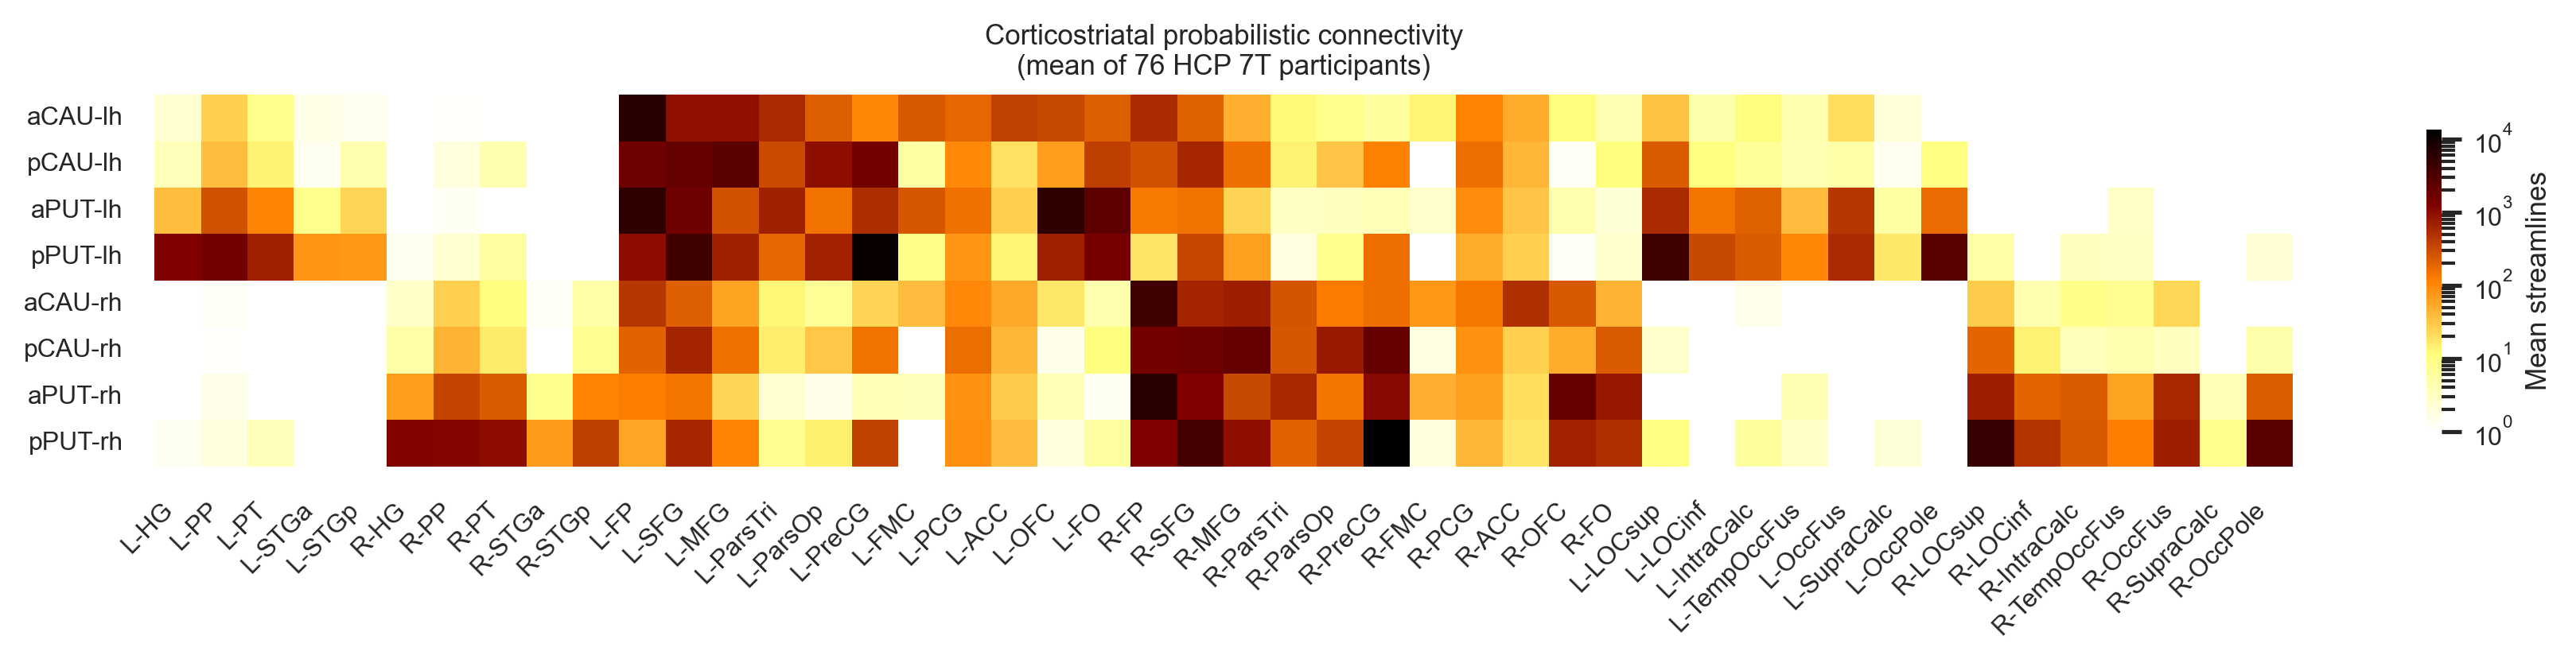

In [90]:
cortical_cols = [r for r in cs_df.columns if r.startswith(('L-', 'R-'))]

# Prefrontal ROIs were added with alternating L/R pairs; regroup to L-all then R-all
_pfc_base = {'FP', 'SFG', 'MFG', 'IFGt', 'IFGo', 'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO'}
pfc_cols  = [c for c in cortical_cols if c[2:] in _pfc_base]
pfc_start = cortical_cols.index(pfc_cols[0])
pfc_end   = cortical_cols.index(pfc_cols[-1]) + 1

reordered = (cortical_cols[:pfc_start]
             + [c for c in pfc_cols if c.startswith('L-')]
             + [c for c in pfc_cols if c.startswith('R-')]
             + cortical_cols[pfc_end:])

cs_df_cortical = cs_df[reordered]
cs_df_cortical_display = cs_df_cortical.copy()
cs_df_cortical_display.columns = [_display_label(c) for c in cs_df_cortical_display.columns]

df_max = cs_df_cortical.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1, 1, figsize=(12, 3), dpi=300)

sns.heatmap(cs_df_cortical_display, ax=ax, cmap="afmhot_r",
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Corticostriatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_all-regions.svg'))
f.tight_layout()


In [ ]:
_aud_base = {'HG', 'PP', 'PT', 'STGa', 'STGp'}
no_vis_cols = [c for c in reordered if c[2:] in (_aud_base | _pfc_base)]
cs_df_no_vis = cs_df[no_vis_cols]
cs_df_no_vis_display = cs_df_no_vis.copy()
cs_df_no_vis_display.columns = [_display_label(c) for c in cs_df_no_vis_display.columns]

df_max_nov = cs_df_no_vis.to_numpy().max()

f2, ax2 = plt.subplots(1, 1, figsize=(9, 3), dpi=300)

sns.heatmap(cs_df_no_vis_display, ax=ax2, cmap="afmhot_r",
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            norm=colors.LogNorm(vmin=np.nanmin(cs_df_no_vis.values[cs_df_no_vis.values > 0]), vmax=df_max_nov),
            square=True)
ax2.set_title(f'Corticostriatal probabilistic connectivity — auditory & prefrontal (mean of {num_participants} HCP 7T participants)')
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_auditory-prefrontal-regions.svg'))
f2.tight_layout()


In [ ]:
df_max = cs_df.to_numpy().max()
cs_df_aud_display = cs_df.iloc[:,8:18].copy()
cs_df_aud_display.columns = [_display_label(c) for c in cs_df_aud_display.columns]

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df_aud_display, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=np.nanmin(cs_df.iloc[:, 8:18].values[cs_df.iloc[:, 8:18].values > 0]), vmax=df_max),
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=np.nanmin(cs_df.iloc[:, 8:18].values[cs_df.iloc[:, 8:18].values > 0]), vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_auditory-regions.svg'))

f.tight_layout()

## Combine separate participants into single dataframe

In [93]:
participant_df_list = []
for i in range(connmats.shape[0]):
    df = pd.DataFrame(connmats[i], index=region_list, columns=region_list)
    df['participant_id'] = i
    participant_df_list.append(df)

In [94]:
striatum_rois = [r for r in region_list if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))]
cortex_rois = [r for r in region_list if r.startswith(('L-', 'R-'))]

filtered_df_list = []
for df in participant_df_list:
    sub_df = df.loc[striatum_rois, cortex_rois]
    sub_df['participant_id'] = df['participant_id'].iloc[0]
    filtered_df_list.append(sub_df)

In [95]:
rostral_caudal_map = {
    'aPUT-lh': 'Rostral', 'aCAU-lh': 'Rostral',
    'pPUT-lh': 'Caudal', 'pCAU-lh': 'Caudal',
    'aPUT-rh': 'Rostral', 'aCAU-rh': 'Rostral',
    'pPUT-rh': 'Caudal', 'pCAU-rh': 'Caudal'
}

for df in filtered_df_list:
    df['Rostral_Caudal'] = df.index.map(rostral_caudal_map)

In [96]:
caudate_putamen_map = {
    'aPUT-lh': 'Putamen', 'aCAU-lh': 'Caudate',
    'pPUT-lh': 'Putamen', 'pCAU-lh': 'Caudate',
    'aPUT-rh': 'Putamen', 'aCAU-rh': 'Caudate',
    'pPUT-rh': 'Putamen', 'pCAU-rh': 'Caudate'
}

for df in filtered_df_list:
    df['Caudate_Putamen'] = df.index.map(caudate_putamen_map)

In [97]:
all_df = pd.concat(filtered_df_list)
all_df = all_df.reset_index().rename(columns={'index': 'Striatum_ROI'})

In [98]:

# Melt to long format
all_long_df = all_df.melt(id_vars=['participant_id', 'Striatum_ROI', 'Rostral_Caudal', 'Caudate_Putamen'], 
                      value_vars=cortex_rois, 
                      var_name='Cortex_ROI', value_name='Connectivity')


In [99]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity
0,0,aPUT-lh,Rostral,Putamen,L-HG,21.862174
1,0,pPUT-lh,Caudal,Putamen,L-HG,1041.838055
2,0,aCAU-lh,Rostral,Caudate,L-HG,1.922404
3,0,pCAU-lh,Caudal,Caudate,L-HG,10.660441
4,0,aPUT-rh,Rostral,Putamen,L-HG,0.093693


In [100]:
# Add hemisphere info before stripping labels
def get_striatum_hemisphere(roi):
    if roi.endswith('-lh'):
        return 'Left'
    elif roi.endswith('-rh'):
        return 'Right'
    else:
        return None

def get_cortex_hemisphere(roi):
    if roi.startswith('L-'):
        return 'Left'
    elif roi.startswith('R-'):
        return 'Right'
    else:
        return None

all_long_df['striatum_hemisphere'] = all_long_df['Striatum_ROI'].apply(get_striatum_hemisphere)
all_long_df['cortex_hemisphere'] = all_long_df['Cortex_ROI'].apply(get_cortex_hemisphere)

# Keep only rows where hemispheres match
all_long_df = all_long_df[all_long_df['striatum_hemisphere'] == all_long_df['cortex_hemisphere']]

# Optionally, create a single 'hemisphere' column and strip hemisphere labels
all_long_df['hemisphere'] = all_long_df['striatum_hemisphere']
all_long_df['Striatum_ROI'] = all_long_df['Striatum_ROI'].apply(lambda x: x[:-3] if x.endswith(('-lh', '-rh')) else x)
all_long_df['Cortex_ROI'] = all_long_df['Cortex_ROI'].apply(lambda x: x[2:] if x.startswith(('L-', 'R-')) else x)

In [101]:
all_long_df.shape

(13984, 9)

In [102]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity,striatum_hemisphere,cortex_hemisphere,hemisphere
0,0,aPUT,Rostral,Putamen,HG,21.862174,Left,Left,Left
1,0,pPUT,Caudal,Putamen,HG,1041.838055,Left,Left,Left
2,0,aCAU,Rostral,Caudate,HG,1.922404,Left,Left,Left
3,0,pCAU,Caudal,Caudate,HG,10.660441,Left,Left,Left
8,1,aPUT,Rostral,Putamen,HG,25.605283,Left,Left,Left


In [103]:
all_long_df.Cortex_ROI.unique()

array(['HG', 'PP', 'PT', 'STGa', 'STGp', 'FP', 'SFG', 'MFG', 'IFGt',
       'IFGo', 'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO', 'LOCsup',
       'LOCinf', 'IntraCalc', 'TempOccFus', 'OccFus', 'SupraCalc',
       'OccPole'], dtype=object)

In [104]:
auditory_rois = ['HG', 'PP', 'PT', 'STGp', 'STGa']
aud_long_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois)]


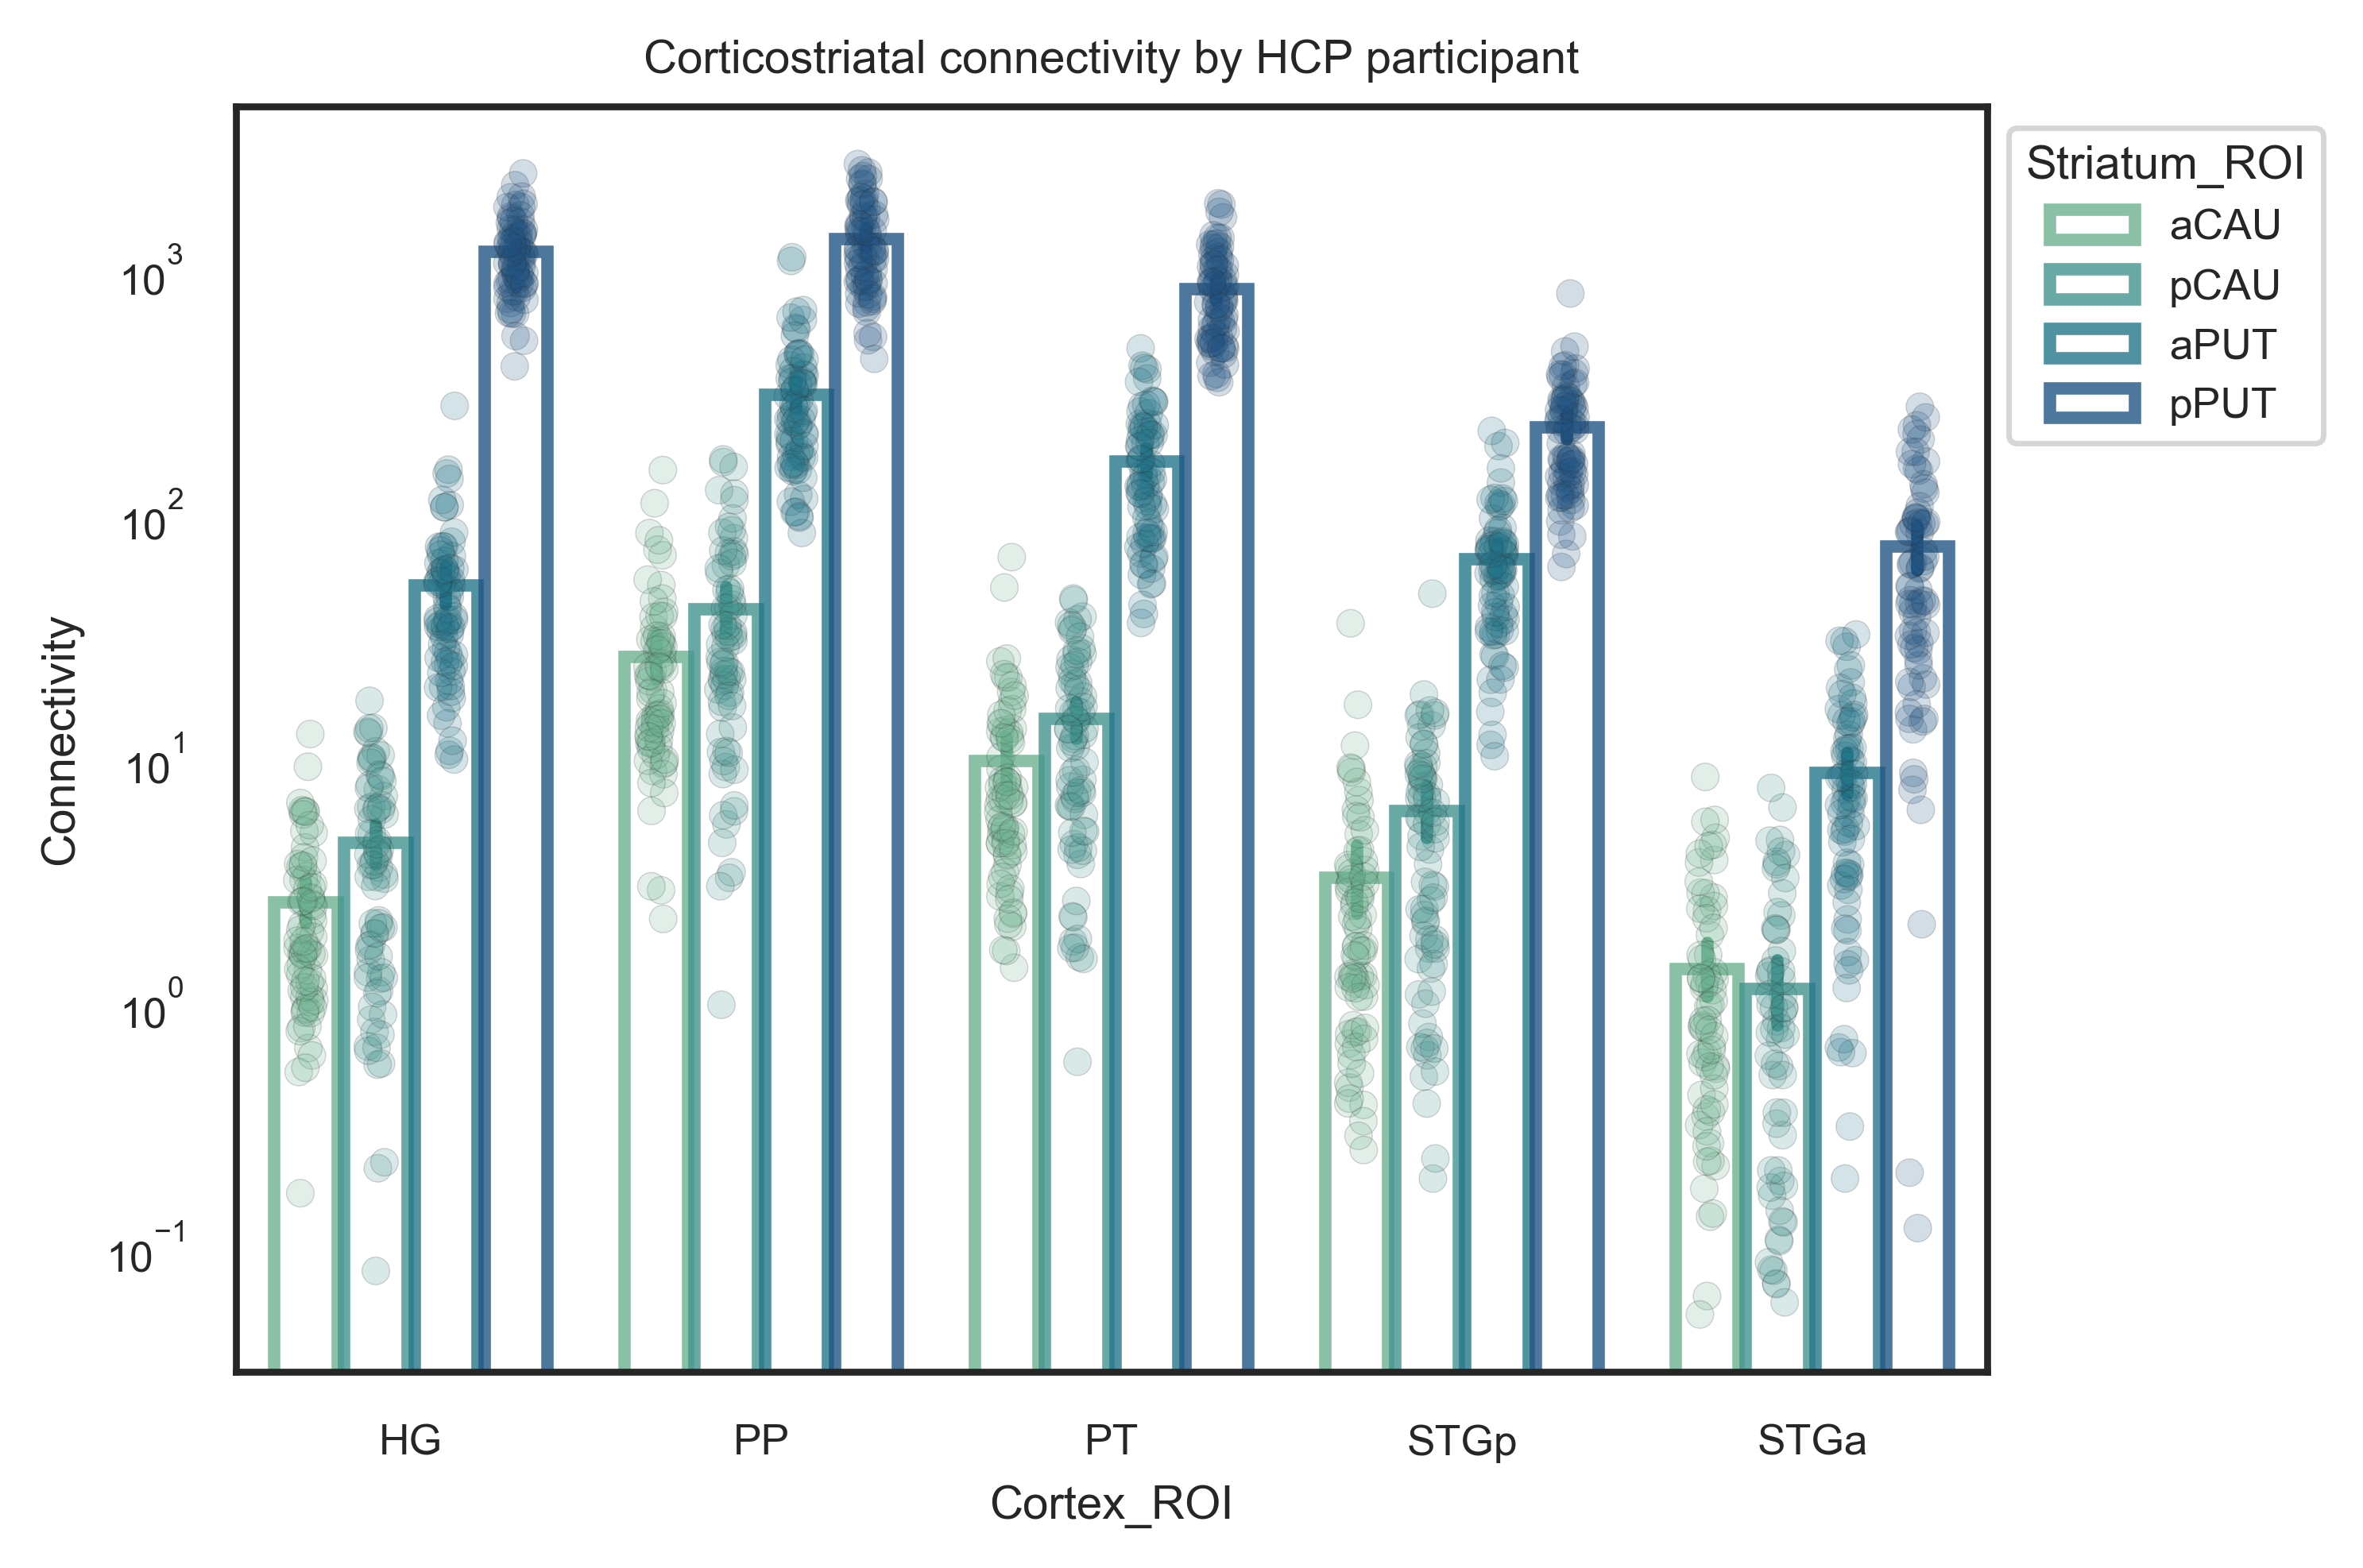

In [105]:
df_collapsed = aud_long_df.groupby(["participant_id", 'Cortex_ROI', 'Striatum_ROI',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=500)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.8, gap=0.1, fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.2,
              alpha=0.2,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
ax.set_ylabel('connectivity (a.u. / mm³)')
#ax.set_ylim([-5, 5])

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'streamline-count_x-cortex_hue-striatum.svg'))

## Across-participant statistics

**Omnibus ANOVAs** are repeated-measures ANOVAs on the untransformed connectivity
values: `statsmodels` `AnovaRM` for the 3- and 4-factor designs, and `pingouin`
`rm_anova` (Greenhouse–Geisser correction + partial η²) for the 2-factor designs.

**Pairwise post-hoc comparisons** use the **Wilcoxon signed-rank test**
(`pg.pairwise_tests(..., parametric=False)`, Benjamini–Hochberg FDR). The
connectivity values are strongly right-skewed with a spike at zero (region pairs
with no streamlines), which breaks the normality assumption of the paired
*t*-test; the rank-based Wilcoxon test is robust to it. The omnibus ANOVAs have
**not** yet been adapted (log-transform or non-parametric) — a known limitation.


In [106]:
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from stats_fmt import export_anova, export_posthoc

STATS_OUT_DIR = 'stats_exports'
os.makedirs(STATS_OUT_DIR, exist_ok=True)

FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)


### All factors

In [108]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_full', STATS_OUT_DIR)


,source,F,df_num,df_den,p,stat_str
0,Caudate_Putamen,740.78,1.0,75.0,p < .001,"F(1, 75) = 740.78, p < .001"
1,Rostral_Caudal,614.90,1.0,75.0,p < .001,"F(1, 75) = 614.90, p < .001"
2,Cortex_ROI,331.43,4.0,300.0,p < .001,"F(4, 300) = 331.43, p < .001"
3,hemisphere,6.74,1.0,75.0,p = .011,"F(1, 75) = 6.74, p = .011"
4,Caudate_Putamen:Rostral_Caudal,613.53,1.0,75.0,p < .001,"F(1, 75) = 613.53, p < .001"
5,Caudate_Putamen:Cortex_ROI,308.56,4.0,300.0,p < .001,"F(4, 300) = 308.56, p < .001"
6,Rostral_Caudal:Cortex_ROI,220.50,4.0,300.0,p < .001,"F(4, 300) = 220.50, p < .001"
7,Caudate_Putamen:hemisphere,6.11,1.0,75.0,p = .016,"F(1, 75) = 6.11, p = .016"
8,Rostral_Caudal:hemisphere,1.10,1.0,75.0,p = .298,"F(1, 75) = 1.10, p = .298"
9,Cortex_ROI:hemisphere,49.97,4.0,300.0,p < .001,"F(4, 300) = 49.97, p < .001"


### No hemisphere

In [109]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_cau_rostral_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,stat_str
0,Caudate_Putamen,740.78,1.0,75.0,p < .001,"F(1, 75) = 740.78, p < .001"
1,Rostral_Caudal,614.90,1.0,75.0,p < .001,"F(1, 75) = 614.90, p < .001"
2,Cortex_ROI,331.43,4.0,300.0,p < .001,"F(4, 300) = 331.43, p < .001"
3,Caudate_Putamen:Rostral_Caudal,613.53,1.0,75.0,p < .001,"F(1, 75) = 613.53, p < .001"
4,Caudate_Putamen:Cortex_ROI,308.56,4.0,300.0,p < .001,"F(4, 300) = 308.56, p < .001"
5,Rostral_Caudal:Cortex_ROI,220.50,4.0,300.0,p < .001,"F(4, 300) = 220.50, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,219.79,4.0,300.0,p < .001,"F(4, 300) = 219.79, p < .001"


### Caudate–Putamen

In [110]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_cau_roi_hemi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,stat_str
0,Caudate_Putamen,740.78,1.0,75.0,p < .001,"F(1, 75) = 740.78, p < .001"
1,Cortex_ROI,331.43,4.0,300.0,p < .001,"F(4, 300) = 331.43, p < .001"
2,hemisphere,6.74,1.0,75.0,p = .011,"F(1, 75) = 6.74, p = .011"
3,Caudate_Putamen:Cortex_ROI,308.56,4.0,300.0,p < .001,"F(4, 300) = 308.56, p < .001"
4,Caudate_Putamen:hemisphere,6.11,1.0,75.0,p = .016,"F(1, 75) = 6.11, p = .016"
5,Cortex_ROI:hemisphere,49.97,4.0,300.0,p < .001,"F(4, 300) = 49.97, p < .001"
6,Caudate_Putamen:Cortex_ROI:hemisphere,55.10,4.0,300.0,p < .001,"F(4, 300) = 55.10, p < .001"


#### 2-way: Cortex ROI x Caudate/Putamen

In [ ]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = aud_long_df.groupby(['participant_id', 'Cortex_ROI', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_roi_cau', STATS_OUT_DIR)


In [111]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_cau_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,-27.22,75.0,p < .001,p = nan,"t(75) = -27.22, p < .001","t(75) = -27.22, q = nan"
1,Cortex_ROI,-,HG,PP,-7.98,75.0,p < .001,p < .001,"t(75) = -7.98, p < .001","t(75) = -7.98, q < .001"
2,Cortex_ROI,-,HG,PT,5.34,75.0,p < .001,p < .001,"t(75) = 5.34, p < .001","t(75) = 5.34, q < .001"
3,Cortex_ROI,-,HG,STGa,24.33,75.0,p < .001,p < .001,"t(75) = 24.33, p < .001","t(75) = 24.33, q < .001"
4,Cortex_ROI,-,HG,STGp,19.10,75.0,p < .001,p < .001,"t(75) = 19.10, p < .001","t(75) = 19.10, q < .001"
5,Cortex_ROI,-,PP,PT,10.76,75.0,p < .001,p < .001,"t(75) = 10.76, p < .001","t(75) = 10.76, q < .001"
6,Cortex_ROI,-,PP,STGa,24.52,75.0,p < .001,p < .001,"t(75) = 24.52, p < .001","t(75) = 24.52, q < .001"
7,Cortex_ROI,-,PP,STGp,21.36,75.0,p < .001,p < .001,"t(75) = 21.36, p < .001","t(75) = 21.36, q < .001"
8,Cortex_ROI,-,PT,STGa,19.82,75.0,p < .001,p < .001,"t(75) = 19.82, p < .001","t(75) = 19.82, q < .001"
9,Cortex_ROI,-,PT,STGp,15.83,75.0,p < .001,p < .001,"t(75) = 15.83, p < .001","t(75) = 15.83, q < .001"


In [112]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Cortex_ROI', 'Caudate_Putamen', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_cau', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,Cortex_ROI,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,-7.98,75.0,p < .001,p < .001,"t(75) = -7.98, p < .001","t(75) = -7.98, q < .001"
1,Cortex_ROI,-,HG,PT,5.34,75.0,p < .001,p < .001,"t(75) = 5.34, p < .001","t(75) = 5.34, q < .001"
2,Cortex_ROI,-,HG,STGa,24.33,75.0,p < .001,p < .001,"t(75) = 24.33, p < .001","t(75) = 24.33, q < .001"
3,Cortex_ROI,-,HG,STGp,19.10,75.0,p < .001,p < .001,"t(75) = 19.10, p < .001","t(75) = 19.10, q < .001"
4,Cortex_ROI,-,PP,PT,10.76,75.0,p < .001,p < .001,"t(75) = 10.76, p < .001","t(75) = 10.76, q < .001"
5,Cortex_ROI,-,PP,STGa,24.52,75.0,p < .001,p < .001,"t(75) = 24.52, p < .001","t(75) = 24.52, q < .001"
6,Cortex_ROI,-,PP,STGp,21.36,75.0,p < .001,p < .001,"t(75) = 21.36, p < .001","t(75) = 21.36, q < .001"
7,Cortex_ROI,-,PT,STGa,19.82,75.0,p < .001,p < .001,"t(75) = 19.82, p < .001","t(75) = 19.82, q < .001"
8,Cortex_ROI,-,PT,STGp,15.83,75.0,p < .001,p < .001,"t(75) = 15.83, p < .001","t(75) = 15.83, q < .001"
9,Cortex_ROI,-,STGa,STGp,-14.77,75.0,p < .001,p < .001,"t(75) = -14.77, p < .001","t(75) = -14.77, q < .001"


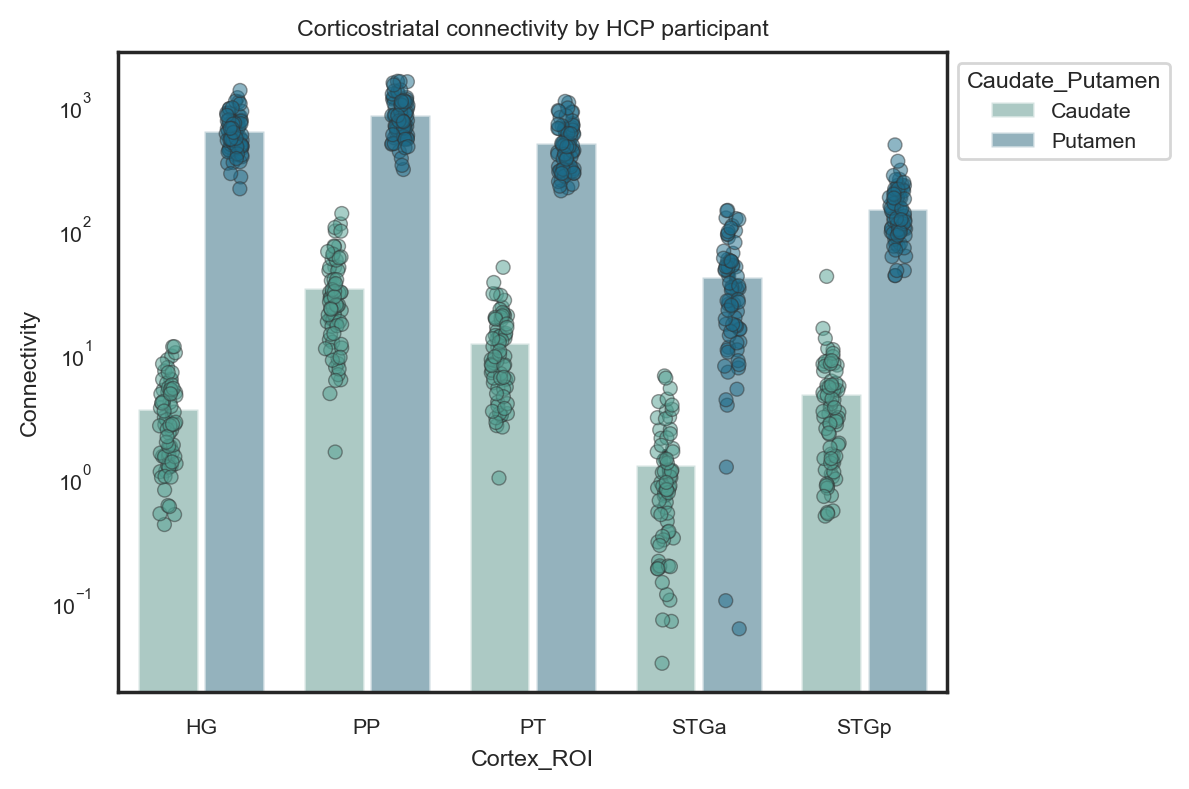

In [113]:
df_collapsed = aud_long_df.groupby(["participant_id", 'Cortex_ROI', 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
ax.set_ylabel('connectivity (a.u. / mm³)')
#ax.set_ylim([-5, 5])

fig.tight_layout()


In [114]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_hemi_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,hemisphere,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,-2.60,75.0,p = .011,p = nan,"t(75) = -2.60, p = .011","t(75) = -2.60, q = nan"
1,Cortex_ROI,-,HG,PP,-7.98,75.0,p < .001,p < .001,"t(75) = -7.98, p < .001","t(75) = -7.98, q < .001"
2,Cortex_ROI,-,HG,PT,5.34,75.0,p < .001,p < .001,"t(75) = 5.34, p < .001","t(75) = 5.34, q < .001"
3,Cortex_ROI,-,HG,STGa,24.33,75.0,p < .001,p < .001,"t(75) = 24.33, p < .001","t(75) = 24.33, q < .001"
4,Cortex_ROI,-,HG,STGp,19.10,75.0,p < .001,p < .001,"t(75) = 19.10, p < .001","t(75) = 19.10, q < .001"
5,Cortex_ROI,-,PP,PT,10.76,75.0,p < .001,p < .001,"t(75) = 10.76, p < .001","t(75) = 10.76, q < .001"
6,Cortex_ROI,-,PP,STGa,24.52,75.0,p < .001,p < .001,"t(75) = 24.52, p < .001","t(75) = 24.52, q < .001"
7,Cortex_ROI,-,PP,STGp,21.36,75.0,p < .001,p < .001,"t(75) = 21.36, p < .001","t(75) = 21.36, q < .001"
8,Cortex_ROI,-,PT,STGa,19.82,75.0,p < .001,p < .001,"t(75) = 19.82, p < .001","t(75) = 19.82, q < .001"
9,Cortex_ROI,-,PT,STGp,15.83,75.0,p < .001,p < .001,"t(75) = 15.83, p < .001","t(75) = 15.83, q < .001"


In [115]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,-7.98,75.0,p < .001,p < .001,"t(75) = -7.98, p < .001","t(75) = -7.98, q < .001"
1,Cortex_ROI,-,HG,PT,5.34,75.0,p < .001,p < .001,"t(75) = 5.34, p < .001","t(75) = 5.34, q < .001"
2,Cortex_ROI,-,HG,STGa,24.33,75.0,p < .001,p < .001,"t(75) = 24.33, p < .001","t(75) = 24.33, q < .001"
3,Cortex_ROI,-,HG,STGp,19.10,75.0,p < .001,p < .001,"t(75) = 19.10, p < .001","t(75) = 19.10, q < .001"
4,Cortex_ROI,-,PP,PT,10.76,75.0,p < .001,p < .001,"t(75) = 10.76, p < .001","t(75) = 10.76, q < .001"
5,Cortex_ROI,-,PP,STGa,24.52,75.0,p < .001,p < .001,"t(75) = 24.52, p < .001","t(75) = 24.52, q < .001"
6,Cortex_ROI,-,PP,STGp,21.36,75.0,p < .001,p < .001,"t(75) = 21.36, p < .001","t(75) = 21.36, q < .001"
7,Cortex_ROI,-,PT,STGa,19.82,75.0,p < .001,p < .001,"t(75) = 19.82, p < .001","t(75) = 19.82, q < .001"
8,Cortex_ROI,-,PT,STGp,15.83,75.0,p < .001,p < .001,"t(75) = 15.83, p < .001","t(75) = 15.83, q < .001"
9,Cortex_ROI,-,STGa,STGp,-14.77,75.0,p < .001,p < .001,"t(75) = -14.77, p < .001","t(75) = -14.77, q < .001"


In [116]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise)
export_posthoc(pairwise, 'aud_striatum_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,Striatum_ROI,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Striatum_ROI,-,aCAU,aPUT,-16.67,75.0,p < .001,p < .001,"t(75) = -16.67, p < .001","t(75) = -16.67, q < .001"
1,Striatum_ROI,-,aCAU,pCAU,-5.17,75.0,p < .001,p < .001,"t(75) = -5.17, p < .001","t(75) = -5.17, q < .001"
2,Striatum_ROI,-,aCAU,pPUT,-26.84,75.0,p < .001,p < .001,"t(75) = -26.84, p < .001","t(75) = -26.84, q < .001"
3,Striatum_ROI,-,aPUT,pCAU,15.35,75.0,p < .001,p < .001,"t(75) = 15.35, p < .001","t(75) = 15.35, q < .001"
4,Striatum_ROI,-,aPUT,pPUT,-24.80,75.0,p < .001,p < .001,"t(75) = -24.80, p < .001","t(75) = -24.80, q < .001"
5,Striatum_ROI,-,pCAU,pPUT,-26.76,75.0,p < .001,p < .001,"t(75) = -26.76, p < .001","t(75) = -26.76, q < .001"
6,hemisphere,-,Left,Right,-2.60,75.0,p = .011,p = nan,"t(75) = -2.60, p = .011","t(75) = -2.60, q = nan"
7,Striatum_ROI * hemisphere,aCAU,Left,Right,-1.08,75.0,p = .284,p = .368,"t(75) = -1.08, p = .284","t(75) = -1.08, q = .368"
8,Striatum_ROI * hemisphere,aPUT,Left,Right,-7.10,75.0,p < .001,p < .001,"t(75) = -7.10, p < .001","t(75) = -7.10, q < .001"
9,Striatum_ROI * hemisphere,pCAU,Left,Right,-1.61,75.0,p = .111,p = .222,"t(75) = -1.61, p = .111","t(75) = -1.61, q = .222"


### Rostral–caudal

In [117]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_rostral_hemi_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,stat_str
0,Rostral_Caudal,614.90,1.0,75.0,p < .001,"F(1, 75) = 614.90, p < .001"
1,hemisphere,6.74,1.0,75.0,p = .011,"F(1, 75) = 6.74, p = .011"
2,Cortex_ROI,331.43,4.0,300.0,p < .001,"F(4, 300) = 331.43, p < .001"
3,Rostral_Caudal:hemisphere,1.10,1.0,75.0,p = .298,"F(1, 75) = 1.10, p = .298"
4,Rostral_Caudal:Cortex_ROI,220.50,4.0,300.0,p < .001,"F(4, 300) = 220.50, p < .001"
5,hemisphere:Cortex_ROI,49.97,4.0,300.0,p < .001,"F(4, 300) = 49.97, p < .001"
6,Rostral_Caudal:hemisphere:Cortex_ROI,43.00,4.0,300.0,p < .001,"F(4, 300) = 43.00, p < .001"


#### 2-way: Cortex ROI x Rostral/Caudal

In [ ]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = aud_long_df.groupby(['participant_id', 'Cortex_ROI', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_roi_rostral', STATS_OUT_DIR)


In [118]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_hemi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,-2.60,75.0,p = .011,p = nan,"t(75) = -2.60, p = .011","t(75) = -2.60, q = nan"
1,Rostral_Caudal,-,Caudal,Rostral,24.80,75.0,p < .001,p = nan,"t(75) = 24.80, p < .001","t(75) = 24.80, q = nan"
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,22.03,75.0,p < .001,p < .001,"t(75) = 22.03, p < .001","t(75) = 22.03, q < .001"
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,20.62,75.0,p < .001,p < .001,"t(75) = 20.62, p < .001","t(75) = 20.62, q < .001"


In [119]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Rostral_Caudal', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_rostral_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Rostral_Caudal', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Rostral_Caudal,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Rostral_Caudal,-,Caudal,Rostral,24.80,75.0,p < .001,p = nan,"t(75) = 24.80, p < .001","t(75) = 24.80, q = nan"
1,hemisphere,-,Left,Right,-2.60,75.0,p = .011,p = nan,"t(75) = -2.60, p = .011","t(75) = -2.60, q = nan"
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,-0.98,75.0,p = .330,p = .330,"t(75) = -0.98, p = .330","t(75) = -0.98, q = .330"
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,-6.96,75.0,p < .001,p < .001,"t(75) = -6.96, p < .001","t(75) = -6.96, q < .001"


In [120]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,-7.98,75.0,p < .001,p < .001,"t(75) = -7.98, p < .001","t(75) = -7.98, q < .001"
1,Cortex_ROI,-,HG,PT,5.34,75.0,p < .001,p < .001,"t(75) = 5.34, p < .001","t(75) = 5.34, q < .001"
2,Cortex_ROI,-,HG,STGa,24.33,75.0,p < .001,p < .001,"t(75) = 24.33, p < .001","t(75) = 24.33, q < .001"
3,Cortex_ROI,-,HG,STGp,19.10,75.0,p < .001,p < .001,"t(75) = 19.10, p < .001","t(75) = 19.10, q < .001"
4,Cortex_ROI,-,PP,PT,10.76,75.0,p < .001,p < .001,"t(75) = 10.76, p < .001","t(75) = 10.76, q < .001"
5,Cortex_ROI,-,PP,STGa,24.52,75.0,p < .001,p < .001,"t(75) = 24.52, p < .001","t(75) = 24.52, q < .001"
6,Cortex_ROI,-,PP,STGp,21.36,75.0,p < .001,p < .001,"t(75) = 21.36, p < .001","t(75) = 21.36, q < .001"
7,Cortex_ROI,-,PT,STGa,19.82,75.0,p < .001,p < .001,"t(75) = 19.82, p < .001","t(75) = 19.82, q < .001"
8,Cortex_ROI,-,PT,STGp,15.83,75.0,p < .001,p < .001,"t(75) = 15.83, p < .001","t(75) = 15.83, q < .001"
9,Cortex_ROI,-,STGa,STGp,-14.77,75.0,p < .001,p < .001,"t(75) = -14.77, p < .001","t(75) = -14.77, q < .001"


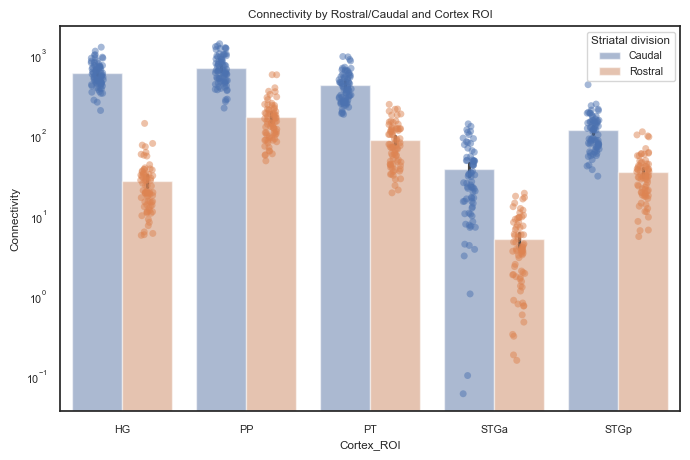

In [121]:
df_collapsed = aud_long_df.groupby(["participant_id", 'Cortex_ROI', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Striatal division') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.ylabel('connectivity (a.u. / mm³)')
plt.show()

In [122]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_hemi2', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,-7.98,75.0,p < .001,p < .001,"t(75) = -7.98, p < .001","t(75) = -7.98, q < .001"
1,Cortex_ROI,-,HG,PT,5.34,75.0,p < .001,p < .001,"t(75) = 5.34, p < .001","t(75) = 5.34, q < .001"
2,Cortex_ROI,-,HG,STGa,24.33,75.0,p < .001,p < .001,"t(75) = 24.33, p < .001","t(75) = 24.33, q < .001"
3,Cortex_ROI,-,HG,STGp,19.10,75.0,p < .001,p < .001,"t(75) = 19.10, p < .001","t(75) = 19.10, q < .001"
4,Cortex_ROI,-,PP,PT,10.76,75.0,p < .001,p < .001,"t(75) = 10.76, p < .001","t(75) = 10.76, q < .001"
5,Cortex_ROI,-,PP,STGa,24.52,75.0,p < .001,p < .001,"t(75) = 24.52, p < .001","t(75) = 24.52, q < .001"
6,Cortex_ROI,-,PP,STGp,21.36,75.0,p < .001,p < .001,"t(75) = 21.36, p < .001","t(75) = 21.36, q < .001"
7,Cortex_ROI,-,PT,STGa,19.82,75.0,p < .001,p < .001,"t(75) = 19.82, p < .001","t(75) = 19.82, q < .001"
8,Cortex_ROI,-,PT,STGp,15.83,75.0,p < .001,p < .001,"t(75) = 15.83, p < .001","t(75) = 15.83, q < .001"
9,Cortex_ROI,-,STGa,STGp,-14.77,75.0,p < .001,p < .001,"t(75) = -14.77, p < .001","t(75) = -14.77, q < .001"


In [123]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise)
export_posthoc(pairwise, 'aud_striatum_hemi2', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,Striatum_ROI,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Striatum_ROI,-,aCAU,aPUT,-16.67,75.0,p < .001,p < .001,"t(75) = -16.67, p < .001","t(75) = -16.67, q < .001"
1,Striatum_ROI,-,aCAU,pCAU,-5.17,75.0,p < .001,p < .001,"t(75) = -5.17, p < .001","t(75) = -5.17, q < .001"
2,Striatum_ROI,-,aCAU,pPUT,-26.84,75.0,p < .001,p < .001,"t(75) = -26.84, p < .001","t(75) = -26.84, q < .001"
3,Striatum_ROI,-,aPUT,pCAU,15.35,75.0,p < .001,p < .001,"t(75) = 15.35, p < .001","t(75) = 15.35, q < .001"
4,Striatum_ROI,-,aPUT,pPUT,-24.80,75.0,p < .001,p < .001,"t(75) = -24.80, p < .001","t(75) = -24.80, q < .001"
5,Striatum_ROI,-,pCAU,pPUT,-26.76,75.0,p < .001,p < .001,"t(75) = -26.76, p < .001","t(75) = -26.76, q < .001"
6,hemisphere,-,Left,Right,-2.60,75.0,p = .011,p = nan,"t(75) = -2.60, p = .011","t(75) = -2.60, q = nan"
7,Striatum_ROI * hemisphere,aCAU,Left,Right,-1.08,75.0,p = .284,p = .368,"t(75) = -1.08, p = .284","t(75) = -1.08, q = .368"
8,Striatum_ROI * hemisphere,aPUT,Left,Right,-7.10,75.0,p < .001,p < .001,"t(75) = -7.10, p < .001","t(75) = -7.10, q < .001"
9,Striatum_ROI * hemisphere,pCAU,Left,Right,-1.61,75.0,p = .111,p = .222,"t(75) = -1.61, p = .111","t(75) = -1.61, q = .222"


### Auditory vs. Prefrontal

In [124]:
auditory_rois   = ['HG', 'PP', 'PT', 'STGa', 'STGp']
prefrontal_rois = PREFRONTAL_ROIS
                  #['FP', 'SFG', 'MFG', 'PreCG', 
                  # 'IFGt', 'IFGo',
                  # 'FMC', 'PCG', 'ACC', 'OFC', 'FO']

category_map = {r: 'Auditory'   for r in auditory_rois}
category_map.update({r: 'Prefrontal' for r in prefrontal_rois})

aud_pfc_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois + prefrontal_rois)].copy()
aud_pfc_df['Cortex_Category'] = aud_pfc_df['Cortex_ROI'].map(category_map)

In [ ]:
# 2-way RM-ANOVA via pingouin: Greenhouse-Geisser correction + partial eta^2.
# pingouin needs one value per subject x cell, so average over the other
# factors first (Cortex_ROI, hemisphere, Rostral_Caudal) -- this is what
# AnovaRM(aggregate_func='mean') did implicitly.
_d = aud_pfc_df.groupby(['participant_id', 'Cortex_Category', 'Caudate_Putamen'],
                        as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_Category', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_pfc_category', STATS_OUT_DIR)


In [126]:
pairwise = pg.pairwise_tests(data=aud_pfc_df,
                             dv='Connectivity',
                             within=['Cortex_Category', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Cortex_Category', 'A', 'B', 'W_val', 'p_unc', 'hedges']]
export_posthoc(pairwise, 'aud_pfc_category_cau', STATS_OUT_DIR)


,Contrast,Cortex_Category,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_Category,-,Auditory,Prefrontal,-15.70,75.0,p < .001,p = nan,"t(75) = -15.70, p < .001","t(75) = -15.70, q = nan"
1,Caudate_Putamen,-,Caudate,Putamen,-25.96,75.0,p < .001,p = nan,"t(75) = -25.96, p < .001","t(75) = -25.96, q = nan"
2,Cortex_Category * Caudate_Putamen,Auditory,Caudate,Putamen,-27.22,75.0,p < .001,p < .001,"t(75) = -27.22, p < .001","t(75) = -27.22, q < .001"
3,Cortex_Category * Caudate_Putamen,Prefrontal,Caudate,Putamen,-17.55,75.0,p < .001,p < .001,"t(75) = -17.55, p < .001","t(75) = -17.55, q < .001"


In [127]:
pairwise = pg.pairwise_tests(data=aud_pfc_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Cortex_Category'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'hedges']]
export_posthoc(pairwise, 'aud_pfc_cau_category', STATS_OUT_DIR)


,Contrast,Caudate_Putamen,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,-25.96,75.0,p < .001,p = nan,"t(75) = -25.96, p < .001","t(75) = -25.96, q = nan"
1,Cortex_Category,-,Auditory,Prefrontal,-15.70,75.0,p < .001,p = nan,"t(75) = -15.70, p < .001","t(75) = -15.70, q = nan"
2,Caudate_Putamen * Cortex_Category,Caudate,Auditory,Prefrontal,-15.05,75.0,p < .001,p < .001,"t(75) = -15.05, p < .001","t(75) = -15.05, q < .001"
3,Caudate_Putamen * Cortex_Category,Putamen,Auditory,Prefrontal,-10.73,75.0,p < .001,p < .001,"t(75) = -10.73, p < .001","t(75) = -10.73, q < .001"


/var/folders/5c/_fg_mvnx2dv1jhkw5xg5fv1h0000gq/T/ipykernel_64919/207512192.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_display_label(r) for r in PREFRONTAL_ROIS])


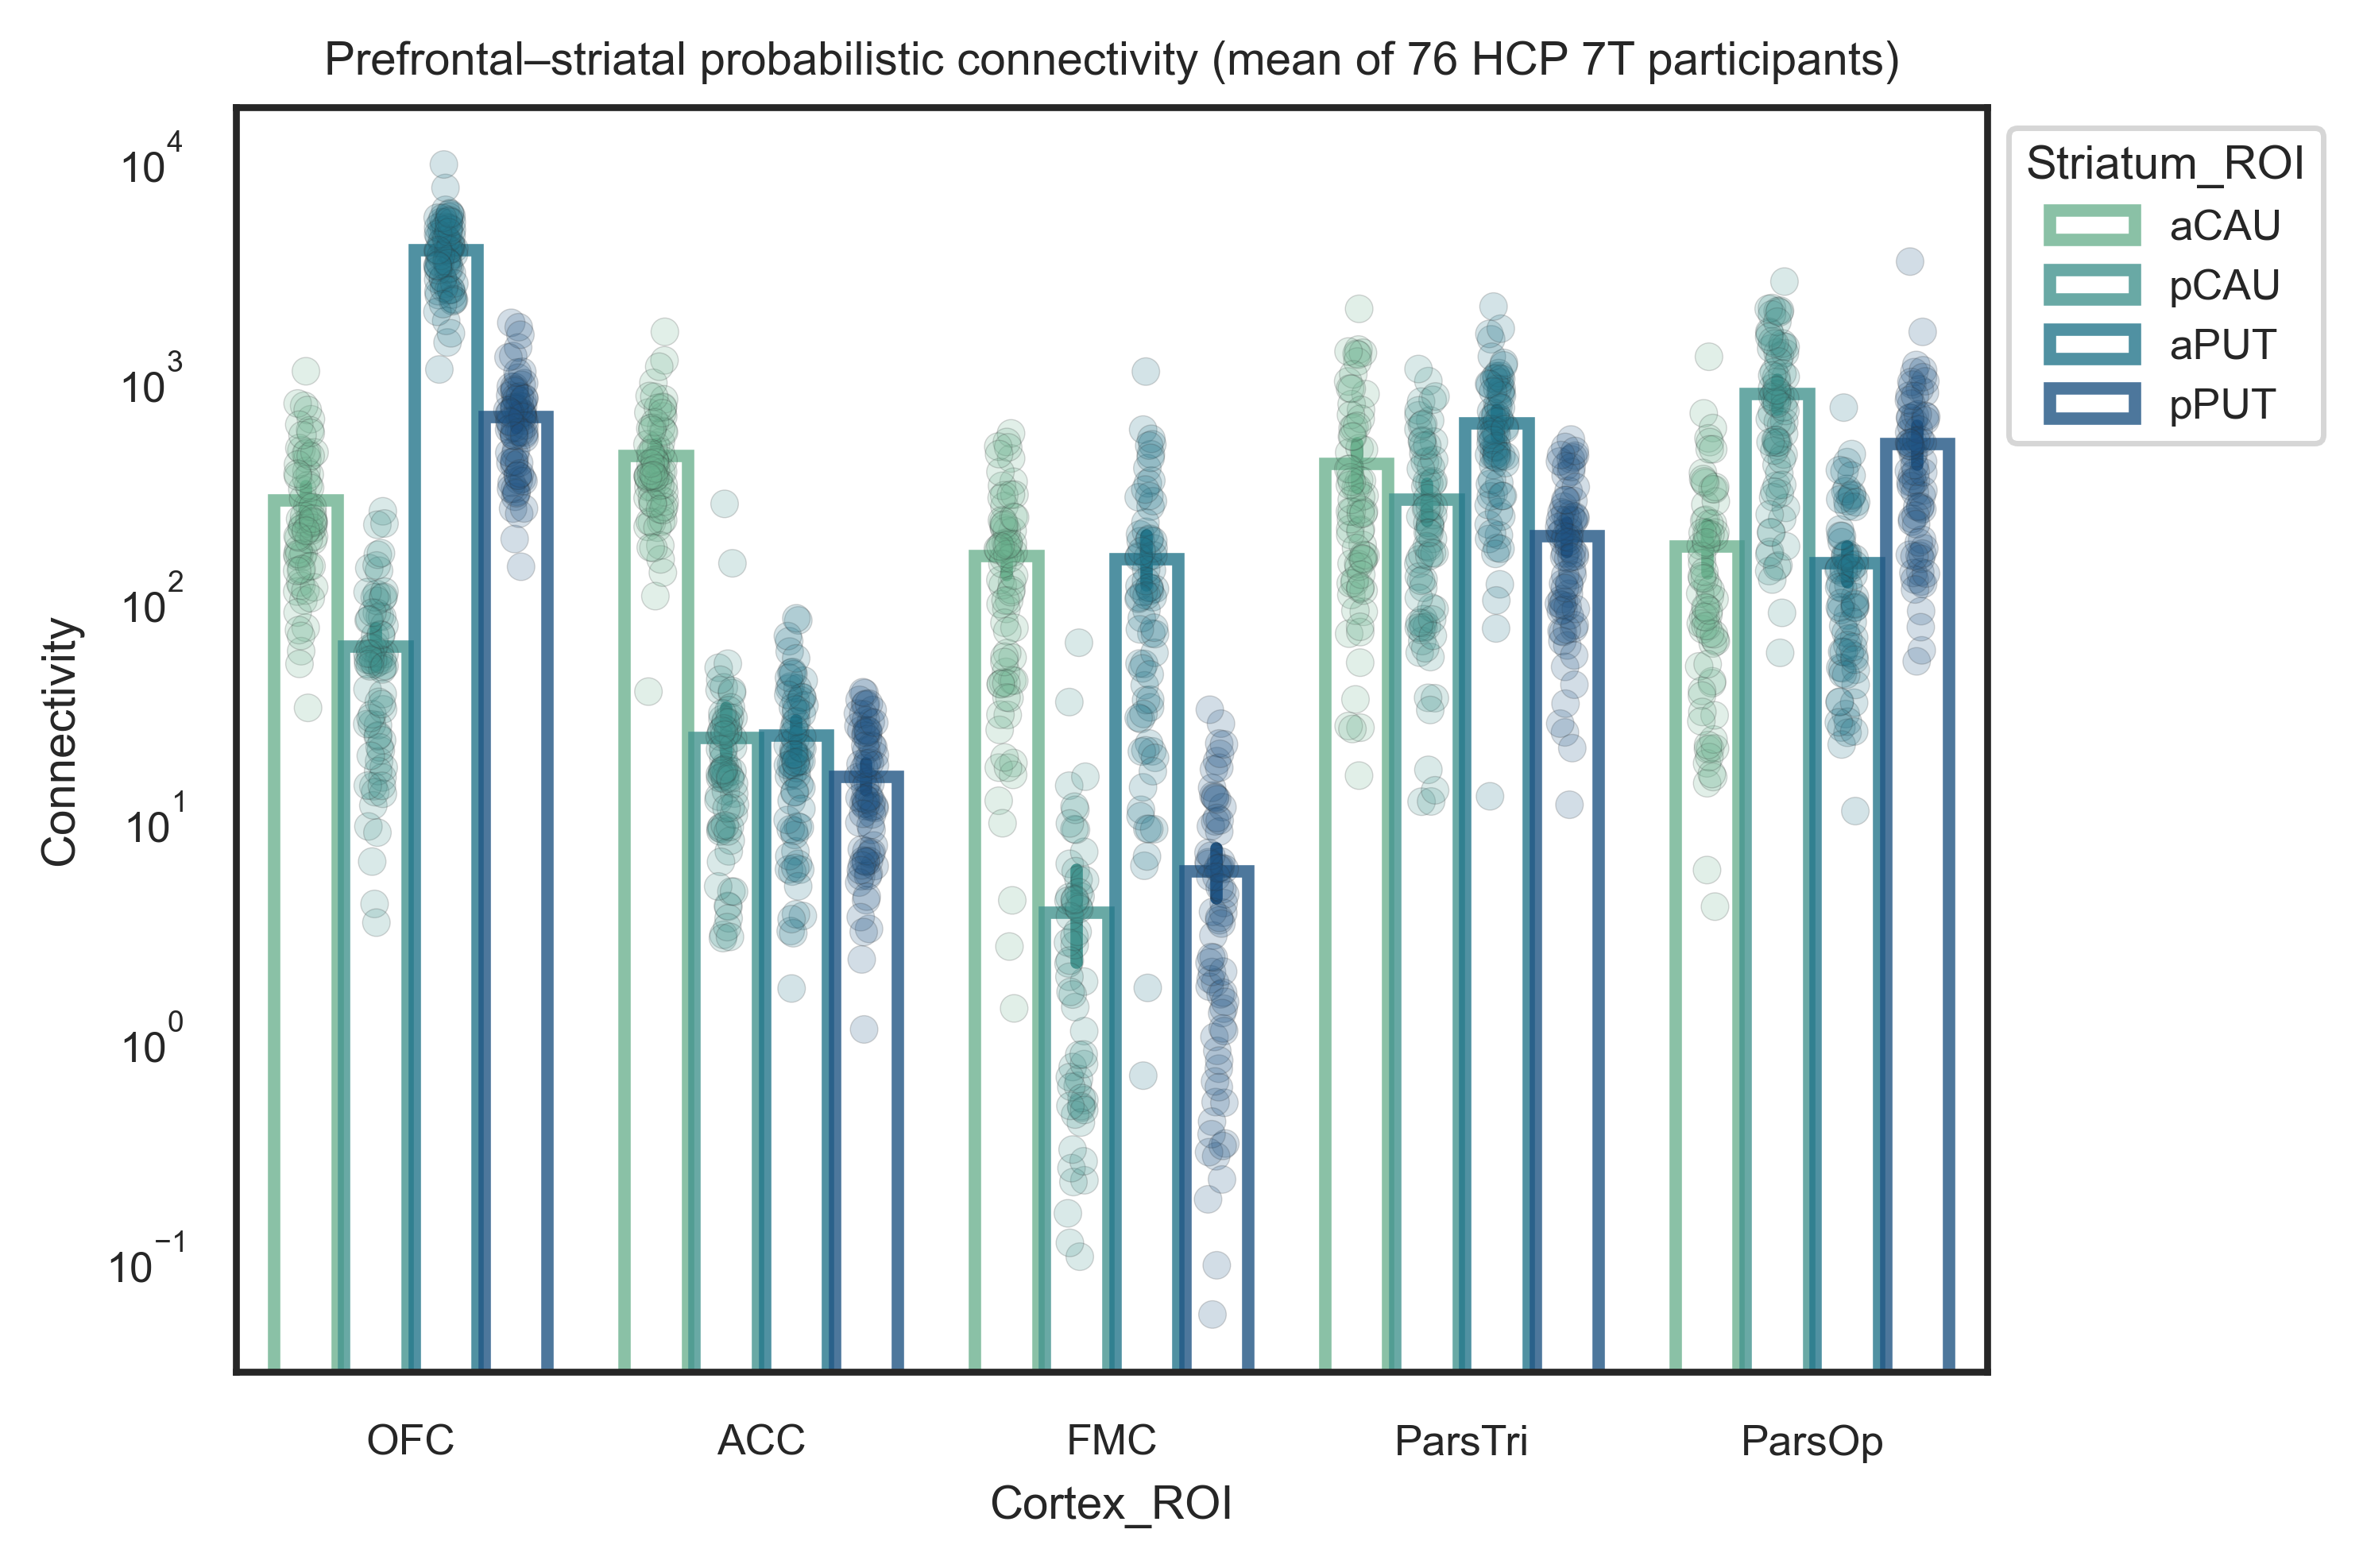

In [146]:
pfc_df = aud_pfc_df[aud_pfc_df['Cortex_Category'] == 'Prefrontal']
pfc_df = pfc_df[pfc_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]

df_collapsed_pfc = pfc_df.groupby(['participant_id', 'Cortex_ROI', 'Striatum_ROI'],
                                   as_index=False).agg({'Connectivity': 'mean'})

fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=500)

sns.barplot(data=df_collapsed_pfc,
            x='Cortex_ROI', y='Connectivity',
            order=PREFRONTAL_ROIS,
            hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
            palette='crest',
            alpha=0.8, gap=0.1, fill=False,
            ax=ax)
sns.stripplot(data=df_collapsed_pfc,
              x='Cortex_ROI', y='Connectivity',
              order=PREFRONTAL_ROIS,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True, jitter=True,
              linewidth=0.2, alpha=0.2,
              legend=None,
              ax=ax)

ax.set_xticklabels([_display_label(r) for r in PREFRONTAL_ROIS])
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))
ax.set_title(f'Prefrontal–striatal probabilistic connectivity (mean of {num_participants} HCP 7T participants)')
plt.yscale('log')
ax.set_ylabel('connectivity (a.u. / mm³)')

fig.savefig(os.path.join(FIGURES_DIR, 'streamline-count_x-prefrontal_hue-striatum.svg'))
fig.tight_layout()


### PFC statistics

In [129]:
pfc_long_df = all_long_df[all_long_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]


#### All factors

In [130]:
aov = AnovaRM(pfc_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere']).fit()
aov.summary()
export_anova(aov, 'pfc_full', STATS_OUT_DIR)


,source,F,df_num,df_den,p,stat_str
0,Caudate_Putamen,307.92,1.0,75.0,p < .001,"F(1, 75) = 307.92, p < .001"
1,Rostral_Caudal,379.60,1.0,75.0,p < .001,"F(1, 75) = 379.60, p < .001"
2,Cortex_ROI,344.60,4.0,300.0,p < .001,"F(4, 300) = 344.60, p < .001"
3,hemisphere,172.16,1.0,75.0,p < .001,"F(1, 75) = 172.16, p < .001"
4,Caudate_Putamen:Rostral_Caudal,334.17,1.0,75.0,p < .001,"F(1, 75) = 334.17, p < .001"
5,Caudate_Putamen:Cortex_ROI,471.99,4.0,300.0,p < .001,"F(4, 300) = 471.99, p < .001"
6,Rostral_Caudal:Cortex_ROI,365.30,4.0,300.0,p < .001,"F(4, 300) = 365.30, p < .001"
7,Caudate_Putamen:hemisphere,158.44,1.0,75.0,p < .001,"F(1, 75) = 158.44, p < .001"
8,Rostral_Caudal:hemisphere,130.27,1.0,75.0,p < .001,"F(1, 75) = 130.27, p < .001"
9,Cortex_ROI:hemisphere,102.93,4.0,300.0,p < .001,"F(4, 300) = 102.93, p < .001"


#### No hemisphere

In [131]:
aov = AnovaRM(pfc_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()
aov.summary()
export_anova(aov, 'pfc_cau_rostral_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,stat_str
0,Caudate_Putamen,307.92,1.0,75.0,p < .001,"F(1, 75) = 307.92, p < .001"
1,Rostral_Caudal,379.60,1.0,75.0,p < .001,"F(1, 75) = 379.60, p < .001"
2,Cortex_ROI,344.60,4.0,300.0,p < .001,"F(4, 300) = 344.60, p < .001"
3,Caudate_Putamen:Rostral_Caudal,334.17,1.0,75.0,p < .001,"F(1, 75) = 334.17, p < .001"
4,Caudate_Putamen:Cortex_ROI,471.99,4.0,300.0,p < .001,"F(4, 300) = 471.99, p < .001"
5,Rostral_Caudal:Cortex_ROI,365.30,4.0,300.0,p < .001,"F(4, 300) = 365.30, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,321.10,4.0,300.0,p < .001,"F(4, 300) = 321.10, p < .001"


#### Caudate–Putamen

##### 2-way: Cortex ROI x Caudate/Putamen

In [ ]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = pfc_long_df.groupby(['participant_id', 'Cortex_ROI', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'pfc_roi_cau', STATS_OUT_DIR)


In [132]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_cau_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,-17.55,75.0,p < .001,p = nan,"t(75) = -17.55, p < .001","t(75) = -17.55, q = nan"
1,Cortex_ROI,-,ACC,FMC,6.20,75.0,p < .001,p < .001,"t(75) = 6.20, p < .001","t(75) = 6.20, q < .001"
2,Cortex_ROI,-,ACC,ParsOp,-10.22,75.0,p < .001,p < .001,"t(75) = -10.22, p < .001","t(75) = -10.22, q < .001"
3,Cortex_ROI,-,ACC,ParsTri,-9.51,75.0,p < .001,p < .001,"t(75) = -9.51, p < .001","t(75) = -9.51, q < .001"
4,Cortex_ROI,-,ACC,OFC,-23.77,75.0,p < .001,p < .001,"t(75) = -23.77, p < .001","t(75) = -23.77, q < .001"
5,Cortex_ROI,-,FMC,ParsOp,-11.69,75.0,p < .001,p < .001,"t(75) = -11.69, p < .001","t(75) = -11.69, q < .001"
6,Cortex_ROI,-,FMC,ParsTri,-11.34,75.0,p < .001,p < .001,"t(75) = -11.34, p < .001","t(75) = -11.34, q < .001"
7,Cortex_ROI,-,FMC,OFC,-24.80,75.0,p < .001,p < .001,"t(75) = -24.80, p < .001","t(75) = -24.80, q < .001"
8,Cortex_ROI,-,ParsOp,ParsTri,1.85,75.0,p = .068,p = .068,"t(75) = 1.85, p = .068","t(75) = 1.85, q = .068"
9,Cortex_ROI,-,ParsOp,OFC,-18.16,75.0,p < .001,p < .001,"t(75) = -18.16, p < .001","t(75) = -18.16, q < .001"


In [133]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_roi_cau', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,ACC,FMC,6.20,75.0,p < .001,p < .001,"t(75) = 6.20, p < .001","t(75) = 6.20, q < .001"
1,Cortex_ROI,-,ACC,ParsOp,-10.22,75.0,p < .001,p < .001,"t(75) = -10.22, p < .001","t(75) = -10.22, q < .001"
2,Cortex_ROI,-,ACC,ParsTri,-9.51,75.0,p < .001,p < .001,"t(75) = -9.51, p < .001","t(75) = -9.51, q < .001"
3,Cortex_ROI,-,ACC,OFC,-23.77,75.0,p < .001,p < .001,"t(75) = -23.77, p < .001","t(75) = -23.77, q < .001"
4,Cortex_ROI,-,FMC,ParsOp,-11.69,75.0,p < .001,p < .001,"t(75) = -11.69, p < .001","t(75) = -11.69, q < .001"
5,Cortex_ROI,-,FMC,ParsTri,-11.34,75.0,p < .001,p < .001,"t(75) = -11.34, p < .001","t(75) = -11.34, q < .001"
6,Cortex_ROI,-,FMC,OFC,-24.80,75.0,p < .001,p < .001,"t(75) = -24.80, p < .001","t(75) = -24.80, q < .001"
7,Cortex_ROI,-,ParsOp,ParsTri,1.85,75.0,p = .068,p = .068,"t(75) = 1.85, p = .068","t(75) = 1.85, q = .068"
8,Cortex_ROI,-,ParsOp,OFC,-18.16,75.0,p < .001,p < .001,"t(75) = -18.16, p < .001","t(75) = -18.16, q < .001"
9,Cortex_ROI,-,ParsTri,OFC,-17.20,75.0,p < .001,p < .001,"t(75) = -17.20, p < .001","t(75) = -17.20, q < .001"


#### Rostral–caudal

##### 2-way: Cortex ROI x Rostral/Caudal

In [ ]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = pfc_long_df.groupby(['participant_id', 'Cortex_ROI', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'pfc_roi_rostral', STATS_OUT_DIR)


In [134]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_roi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,t,df,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,ACC,FMC,6.20,75.0,p < .001,p < .001,"t(75) = 6.20, p < .001","t(75) = 6.20, q < .001"
1,Cortex_ROI,-,ACC,ParsOp,-10.22,75.0,p < .001,p < .001,"t(75) = -10.22, p < .001","t(75) = -10.22, q < .001"
2,Cortex_ROI,-,ACC,ParsTri,-9.51,75.0,p < .001,p < .001,"t(75) = -9.51, p < .001","t(75) = -9.51, q < .001"
3,Cortex_ROI,-,ACC,OFC,-23.77,75.0,p < .001,p < .001,"t(75) = -23.77, p < .001","t(75) = -23.77, q < .001"
4,Cortex_ROI,-,FMC,ParsOp,-11.69,75.0,p < .001,p < .001,"t(75) = -11.69, p < .001","t(75) = -11.69, q < .001"
5,Cortex_ROI,-,FMC,ParsTri,-11.34,75.0,p < .001,p < .001,"t(75) = -11.34, p < .001","t(75) = -11.34, q < .001"
6,Cortex_ROI,-,FMC,OFC,-24.80,75.0,p < .001,p < .001,"t(75) = -24.80, p < .001","t(75) = -24.80, q < .001"
7,Cortex_ROI,-,ParsOp,ParsTri,1.85,75.0,p = .068,p = .068,"t(75) = 1.85, p = .068","t(75) = 1.85, q = .068"
8,Cortex_ROI,-,ParsOp,OFC,-18.16,75.0,p < .001,p < .001,"t(75) = -18.16, p < .001","t(75) = -18.16, q < .001"
9,Cortex_ROI,-,ParsTri,OFC,-17.20,75.0,p < .001,p < .001,"t(75) = -17.20, p < .001","t(75) = -17.20, q < .001"


## Sensitivity analysis — log-transformed connectivity

Self-contained repeat of the omnibus ANOVAs on `log(C + c)`, with
`c = ½ · min(non-zero C)` so exact-zero edges map to a finite floor. Builds its
own `*_log_df` frames and touches no existing variable. Outputs get a `_log`
suffix and sit alongside the untransformed `anova_*.tsv`.

Whether to adopt this over the untransformed analysis depends on (a) the
exact-zero fraction (see the *Plot distributions* section) and (b) the residual
normality check below.

In [ ]:
# log-transformed copies of the analysis frames (nothing existing is mutated)
_pos = all_long_df.loc[all_long_df['Connectivity'] > 0, 'Connectivity']
LOG_OFFSET = 0.5 * float(_pos.min())
_zero_frac = float((all_long_df['Connectivity'] == 0).mean())
print(f'log offset c = {LOG_OFFSET:.4g}   ({_zero_frac:.1%} of edges are exactly zero)')

def _to_log(df):
    d = df.dropna(subset=['Connectivity']).copy()
    d['Connectivity'] = np.log(d['Connectivity'].clip(lower=0) + LOG_OFFSET)
    return d

all_log_df = _to_log(all_long_df)
aud_log_df = all_log_df[all_log_df['Cortex_ROI'].isin(AUDITORY_ROIS)]
pfc_log_df = all_log_df[all_log_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]


In [ ]:
# RM-ANOVA assumes normal residuals after removing subject and condition means.
import scipy.stats as sps
_factors = ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere']

def _rm_resid(df):
    y = df['Connectivity'].to_numpy(float)
    y = y - df.groupby('participant_id')['Connectivity'].transform('mean').to_numpy()
    cell = df[_factors].astype(str).agg('-'.join, axis=1).to_numpy()
    return y - pd.Series(y).groupby(cell).transform('mean').to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (frame, tag) in zip(axes,
                            [(all_long_df.dropna(subset=['Connectivity']), 'raw C'),
                             (all_log_df, 'log(C + c)')]):
    r = _rm_resid(frame)
    r = r[np.isfinite(r)]
    sps.probplot(r, plot=ax)
    _r = r if len(r) <= 5000 else np.random.default_rng(0).choice(r, 5000, replace=False)
    W, p = sps.shapiro(_r)
    ax.set_title(f'{tag}   residuals: Shapiro W = {W:.3f}, p = {p:.1e}')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'residual_qq_raw_vs_log.svg'))


In [ ]:
# omnibus ANOVAs on the log scale.  >2 within-factors -> AnovaRM; 2 -> rm_anova.
def _omnibus_log(df, within, label):
    if len(within) > 2:
        aov = AnovaRM(df, aggregate_func='mean', depvar='Connectivity',
                      subject='participant_id', within=within).fit()
        return export_anova(aov, label, STATS_OUT_DIR)
    d = df.groupby(['participant_id'] + within, as_index=False)['Connectivity'].mean()
    aov = pg.rm_anova(data=d, dv='Connectivity', within=within,
                      subject='participant_id', detailed=True, effsize='np2')
    return export_anova(aov, label, STATS_OUT_DIR)

_specs = [
    (aud_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere'], 'aud_full_log'),
    (aud_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI'],               'aud_cau_rostral_roi_log'),
    (aud_log_df, ['Cortex_ROI', 'Caudate_Putamen'],                                 'aud_roi_cau_log'),
    (aud_log_df, ['Cortex_ROI', 'Rostral_Caudal'],                                  'aud_roi_rostral_log'),
    (pfc_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere'], 'pfc_full_log'),
    (pfc_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI'],               'pfc_cau_rostral_roi_log'),
    (pfc_log_df, ['Cortex_ROI', 'Caudate_Putamen'],                                 'pfc_roi_cau_log'),
    (pfc_log_df, ['Cortex_ROI', 'Rostral_Caudal'],                                  'pfc_roi_rostral_log'),
]
for _df, _within, _lbl in _specs:
    print(f'\n=== {_lbl} ===')
    display(_omnibus_log(_df, _within, _lbl))


## Anatomical Connectivity Figure (Yeterian & Pandya 1998 Style)

Schematic figure showing auditory corticostriatal connectivity on a lateral brain view and coronal striatal cross-sections.


In [135]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patches as mpatches
import nibabel as nib
from skimage import measure
import seaborn as sns

In [136]:
# Per-ROI mask files (from atlas_construction.ipynb) + an MNI brain mask.
atlas_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/')
file_prefix = 'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal'

BRAIN_MASK_PATH = os.path.join('/Users/dsj3886/data_local/reference/',
                               'mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/',
                               'mni_icbm152_t1_tal_nlin_asym_09c_mask.nii')

AUDITORY_MASK_PATHS = {
    "HG":   os.path.join(atlas_dir, f'{file_prefix}_L-HG.nii.gz'),
    "PP":   os.path.join(atlas_dir, f'{file_prefix}_L-PP.nii.gz'),
    "PT":   os.path.join(atlas_dir, f'{file_prefix}_L-PT.nii.gz'),
    "STGa": os.path.join(atlas_dir, f'{file_prefix}_L-STGa.nii.gz'),
    "STGp": os.path.join(atlas_dir, f'{file_prefix}_L-STGp.nii.gz'),
}

PREFRONTAL_MASK_PATHS = {
    "OFC":   os.path.join(atlas_dir, f'{file_prefix}_L-OFC.nii.gz'),
    "ACC":   os.path.join(atlas_dir, f'{file_prefix}_L-ACC.nii.gz'),
    "FMC":   os.path.join(atlas_dir, f'{file_prefix}_L-FMC.nii.gz'),
    "MFG":   os.path.join(atlas_dir, f'{file_prefix}_L-MFG.nii.gz'),
    "IFGt":  os.path.join(atlas_dir, f'{file_prefix}_L-IFGt.nii.gz'),
    "IFGo":  os.path.join(atlas_dir, f'{file_prefix}_L-IFGo.nii.gz'),
    "PreCG": os.path.join(atlas_dir, f'{file_prefix}_L-PreCG.nii.gz'),
}

STRIATAL_MASK_PATHS = {
    "aPUT": os.path.join(atlas_dir, f'{file_prefix}_aPUT-lh.nii.gz'),
    "pPUT": os.path.join(atlas_dir, f'{file_prefix}_pPUT-lh.nii.gz'),
    "aCAU": os.path.join(atlas_dir, f'{file_prefix}_aCAU-lh.nii.gz'),
    "pCAU": os.path.join(atlas_dir, f'{file_prefix}_pCAU-lh.nii.gz'),
}


In [137]:
def get_roi_contour(mask_path, axis=1, slice_idx=None):
    """
    Load a binary NIfTI mask and return the largest 2D contour from a slice.

    axis=0 -> sagittal slice
    axis=1 -> coronal slice
    slice_idx: if None, use the slice with the largest cross-sectional area.
    """
    data = nib.load(mask_path).get_fdata()
    if slice_idx is None:
        areas = [np.take(data, i, axis=axis).sum() for i in range(data.shape[axis])]
        slice_idx = int(np.argmax(areas))
    slice_2d = np.take(data, slice_idx, axis=axis)
    contours = measure.find_contours(slice_2d, level=0.5)
    return max(contours, key=len)


def get_best_slice_idx(mask_path, axis):
    """Return the slice index with the largest mask area along the given axis."""
    data = nib.load(mask_path).get_fdata()
    areas = [np.take(data, i, axis=axis).sum() for i in range(data.shape[axis])]
    return int(np.argmax(areas))


In [138]:

CORTEX_ROI      = 'HG'   # highlighted in the brain panel

all_conn = (
    all_long_df[all_long_df['Cortex_ROI'].isin(CORTEX_ROIS)]
    .groupby(['Cortex_ROI', 'Striatum_ROI'])['Connectivity']
    .mean()
    .reset_index()
    .rename(columns={'Connectivity': 'conn_mean'})
)
print(all_conn)


   Cortex_ROI Striatum_ROI    conn_mean
0         ACC         aCAU   446.667387
1         ACC         aPUT    23.776086
2         ACC         pCAU    23.261653
3         ACC         pPUT    15.531474
4         FMC         aCAU   155.766903
5         FMC         aPUT   151.374684
6         FMC         pCAU     3.740185
7         FMC         pPUT     5.752613
8          HG         aCAU     2.618567
9          HG         aPUT    51.953103
10         HG         pCAU     4.590984
11         HG         pPUT  1203.405786
12       IFGo         aCAU   172.314811
13       IFGo         aPUT   144.795436
14       IFGo         pCAU   854.742322
15       IFGo         pPUT   504.599187
16       IFGt         aCAU   411.226153
17       IFGt         aPUT   627.790149
18       IFGt         pCAU   282.730333
19       IFGt         pPUT   192.620436
20        OFC         aCAU   280.379579
21        OFC         aPUT  3842.865961
22        OFC         pCAU    60.707773
23        OFC         pPUT   667.407973


In [139]:
from matplotlib.colors import Normalize as MplNorm, LogNorm, to_rgb
from matplotlib.cm import ScalarMappable

CMAP = plt.cm.YlOrRd

AUDITORY_PALETTE = {
    'HG':   CMAP(0.85),
    'PP':   '#5aafe0',
    'PT':   '#78c679',
    'STGa': '#9970ab',
    'STGp': '#d9a63a',
}

PREFRONTAL_PALETTE = {
    'OFC':   '#e8a838',
    'ACC':   '#d46b6b',
    'FMC':   '#8e5fbf',
    'MFG':   '#4d9de0',
    'IFGt':  '#3bb273',
    'IFGo':  '#e84855',
    'PreCG': '#7f8c8d',
}

# Paint order: last = highest priority (drawn on top).
# Auditory (temporal plane) are given priority over prefrontal.
PAINT_ORDER = ['PreCG', 'IFGo', 'IFGt', 'MFG', 'FMC', 'ACC', 'OFC',
               'STGp', 'STGa', 'PT', 'PP', 'HG']

# Z-shear applied before Y-Z projection.
# Positive value: each voxel at X=x is shifted +x*SHEAR_FACTOR in Z.
# This tilts the projection to look from slightly below, separating the
# superior temporal plane (HG/PP/PT, deeper/more medial) from the lateral
# surface (STGa/STGp, more lateral).
SHEAR_FACTOR = 0.3


def _sheared_footprint(mask_3d, shear_factor, out_nz):
    """Y-Z footprint with Z-shear. Returns bool array (ny, out_nz)."""
    nx, ny, nz = mask_3d.shape
    result = np.zeros((ny, out_nz), dtype=bool)
    for x in range(nx):
        z_shift = int(round(x * shear_factor))
        sl = mask_3d[x] > 0          # (ny, nz)
        src_end = min(nz, out_nz - z_shift)
        dst_start = z_shift
        if src_end > 0 and dst_start < out_nz:
            result[:, dst_start:dst_start + src_end] |= sl[:, :src_end]
    return result


def _make_surface_rgba(brain_mask_path, roi_mask_paths, palette):
    """
    Sheared Y-Z footprint per ROI painted in PAINT_ORDER.
    Returns (rgba (nz_out,ny,4), brain_proj (ny,nz_out), roi_label (ny,nz_out), roi_list).
    """
    brain_data = nib.load(brain_mask_path).get_fdata() > 0
    nx, ny, nz = brain_data.shape
    nz_out = nz + int(nx * SHEAR_FACTOR) + 2   # extra Z room after shearing

    brain_proj = _sheared_footprint(brain_data, SHEAR_FACTOR, nz_out)

    footprints = {
        roi: _sheared_footprint(nib.load(path).get_fdata(), SHEAR_FACTOR, nz_out)
        for roi, path in roi_mask_paths.items()
    }

    rgba = np.zeros((nz_out, ny, 4), dtype=float)
    in_brain = brain_proj.T
    rgba[in_brain, :3] = 0.85
    rgba[in_brain,  3] = 1.0

    roi_list  = list(roi_mask_paths.keys())
    roi_label = np.zeros((ny, nz_out), dtype=int)

    for roi in PAINT_ORDER:
        if roi not in footprints:
            continue
        fp   = footprints[roi]
        mask = fp.T
        rgba[mask, :3] = to_rgb(palette.get(roi, '#888888'))
        rgba[mask,  3] = 1.0
        roi_label[fp] = roi_list.index(roi) + 1

    rgba[~in_brain, 3] = 0.0
    return rgba, brain_proj, roi_label, roi_list, footprints


def draw_brain_panel(ax, brain_mask_path, cortex_mask_paths, striatal_mask_paths):
    combined_palette = {**AUDITORY_PALETTE, **PREFRONTAL_PALETTE}
    rgba, brain_proj, roi_label, roi_list, footprints = _make_surface_rgba(
        brain_mask_path, cortex_mask_paths, combined_palette)

    ny, nz_out = brain_proj.shape
    ax.imshow(rgba, origin='lower', extent=[0, ny, 0, nz_out],
              aspect='equal', interpolation='nearest')

    # Brain silhouette
    brain_contour = max(measure.find_contours(brain_proj.astype(float), level=0.5), key=len)
    ax.plot(brain_contour[:, 0], brain_contour[:, 1], color='black', linewidth=1.5, zorder=4)

    # ROI boundary contours
    for roi, fp in footprints.items():
        contours = measure.find_contours(fp.astype(float), level=0.5)
        for c in contours:
            ax.plot(c[:, 0], c[:, 1], color='black', linewidth=0.6, zorder=5)

    # Labels at painted centroid
    for idx, roi in enumerate(roi_list, start=1):
        ys, zs = np.where(roi_label == idx)
        if len(ys) == 0:
            continue
        is_active = (roi == CORTEX_ROI)
        ax.text(ys.mean(), zs.mean(), _display_label(roi),
                ha='center', va='center', fontsize=7, zorder=6,
                fontweight='bold' if is_active else 'normal',
                color='white' if is_active else 'black')

    # Crop to brain bounding box
    ys, zs = np.where(brain_proj)
    margin = 4
    ax.set_xlim(ys.min() - margin, ys.max() + margin)
    ax.set_ylim(zs.min() - margin, zs.max() + margin)
    ax.set_aspect('equal')
    ax.invert_xaxis()

    ax.axis('off')


def draw_striatal_structure(ax, roi_ant, roi_post, hg_conn_df, striatal_mask_paths, norm, title=None):
    data_ant  = nib.load(striatal_mask_paths[roi_ant]).get_fdata()
    data_post = nib.load(striatal_mask_paths[roi_post]).get_fdata()
    slice_idx = int(np.argmax((data_ant + data_post).sum(axis=(1, 2))))

    for roi, data in [(roi_ant, data_ant), (roi_post, data_post)]:
        row      = hg_conn_df[hg_conn_df["Striatum_ROI"] == roi]
        conn_val = float(row["conn_mean"].values[0]) if not row.empty else 0
        contours = measure.find_contours(data[slice_idx, :, :], level=0.5)
        if not contours:
            continue
        contour = max(contours, key=len)
        verts = np.column_stack([contour[:, 0], contour[:, 1]])
        codes  = [Path.MOVETO] + [Path.LINETO] * (len(verts) - 2) + [Path.CLOSEPOLY]
        ax.add_patch(PathPatch(Path(verts, codes),
                               facecolor=CMAP(norm(conn_val)),
                               edgecolor='black', linewidth=1.5))
        label = 'ant' if roi == roi_ant else 'post'
        ax.text(np.mean(contour[:, 0]), np.mean(contour[:, 1]), label,
                ha='center', va='center', fontsize=6, color='black', alpha=0.7)

    if title:
        ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    ax.autoscale()
    # Tighten limits to the data so no internal whitespace inflates the gap
    margin = 3
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.invert_xaxis()
    ax.axis('off')


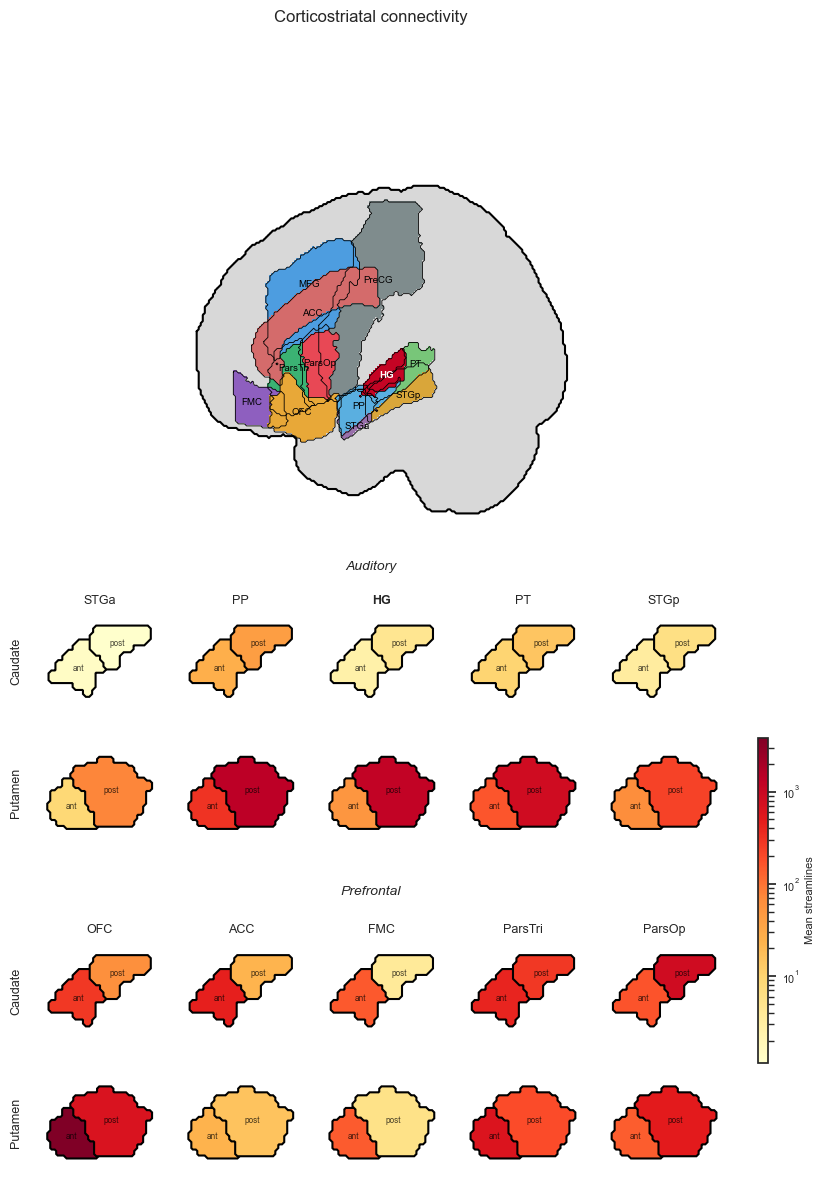

In [140]:
# -- Build figure: brain top, auditory middle, prefrontal bottom --------------
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

vmax     = float(all_conn['conn_mean'].max())
vmin_log = max(float(all_conn['conn_mean'].min()), 1)
norm     = LogNorm(vmin=vmin_log, vmax=vmax)

col_w = 1.8
fig_w = col_w * max(len(AUDITORY_ROIS), len(PREFRONTAL_ROIS))
fig   = plt.figure(figsize=(fig_w, 13))

# Outer grid: brain | auditory (cau+put) | prefrontal (cau+put)
gs_outer = gridspec.GridSpec(3, 1, height_ratios=[2.5, 1.8, 1.8], hspace=0.3)

ax_brain = fig.add_subplot(gs_outer[0])
draw_brain_panel(ax_brain, BRAIN_MASK_PATH, {**AUDITORY_MASK_PATHS, **PREFRONTAL_MASK_PATHS}, STRIATAL_MASK_PATHS)

# ── Auditory section ─────────────────────────────────────────────────────────
gs_aud = gridspec.GridSpecFromSubplotSpec(
    2, len(AUDITORY_ROIS), subplot_spec=gs_outer[1], wspace=0.06, hspace=0.15)

ax_cau_aud_first = ax_put_aud_first = None
for col, roi in enumerate(AUDITORY_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_aud[0, col])
    ax_put = fig.add_subplot(gs_aud[1, col])
    if col == 0:
        ax_cau_aud_first = ax_cau
        ax_put_aud_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(roi, fontsize=9, fontweight='bold' if roi == CORTEX_ROI else 'normal')

ax_cau_aud_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                           xytext=(-8, 0), textcoords='offset points',
                           ha='right', va='center', fontsize=9, rotation=90)
ax_put_aud_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                           xytext=(-8, 0), textcoords='offset points',
                           ha='right', va='center', fontsize=9, rotation=90)

# ── Prefrontal section ───────────────────────────────────────────────────────
gs_pfc = gridspec.GridSpecFromSubplotSpec(
    2, len(PREFRONTAL_ROIS), subplot_spec=gs_outer[2], wspace=0.06, hspace=0.15)

ax_cau_pfc_first = ax_put_pfc_first = None
for col, roi in enumerate(PREFRONTAL_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_pfc[0, col])
    ax_put = fig.add_subplot(gs_pfc[1, col])
    if col == 0:
        ax_cau_pfc_first = ax_cau
        ax_put_pfc_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(_display_label(roi), fontsize=9)

ax_cau_pfc_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)
ax_put_pfc_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)

# ── Section labels: placed in the hspace gap between outer rows ──────────────
fig.canvas.draw()
# midpoint of gap between brain bottom and auditory caudate top
aud_label_y = (ax_cau_aud_first.get_position().y1 + ax_brain.get_position().y0) / 2
# midpoint of gap between auditory putamen bottom and prefrontal caudate top
pfc_label_y = (ax_cau_pfc_first.get_position().y1 + ax_put_aud_first.get_position().y0) / 2
fig.text(0.5, aud_label_y, 'Auditory',   ha='center', va='center', fontsize=10, style='italic')
fig.text(0.5, pfc_label_y, 'Prefrontal', ha='center', va='center', fontsize=10, style='italic')

# ── Shared colorbar ──────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.93, 0.2, 0.012, 0.25])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('connectivity (a.u. / mm³)', fontsize=8)

fig.suptitle('Corticostriatal connectivity', fontsize=12, y=1.01)

fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.png'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.svg'), bbox_inches='tight', dpi=300)
plt.show()


### Surface ROI visualisation (Destrieux approximation)

Renders the auditory / prefrontal ROIs on an fsaverage surface for figure panels. Uses approximate Destrieux labels, independent of the connectivity analysis.

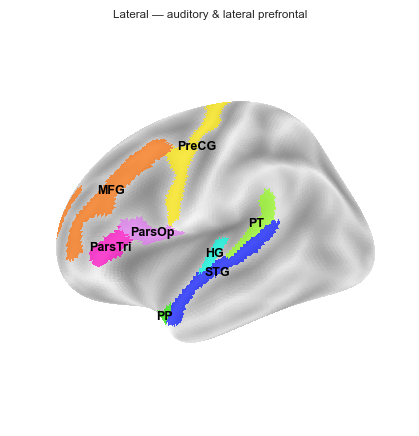

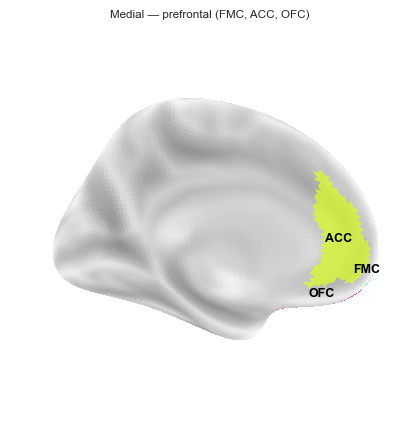

In [141]:
from nilearn import datasets, plotting, surface
import numpy as np

destrieux = datasets.fetch_atlas_surf_destrieux()
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]
parc   = destrieux['map_left']
coords, _ = surface.load_surf_mesh(fsaverage['infl_left'])

# ROI → Destrieux label
auditory_destrieux = {
    'STG':  'G_temp_sup-Lateral',
    'HG':   'G_temp_sup-G_T_transv',
    'PP':   'G_temp_sup-Plan_polar',
    'PT':   'G_temp_sup-Plan_tempo',
}
lateral_pfc_destrieux = {
    'PreCG': 'G_precentral',
    'MFG':   'G_front_middle',
    'IFGt':  'G_front_inf-Triangul',
    'IFGo':  'G_front_inf-Opercular',
}
medial_pfc_destrieux = {
    'FMC': 'G_and_S_frontomargin',
    'ACC': 'G_and_S_cingul-Ant',
    'OFC': 'G_orbital',
}


def make_roi_map(roi_dict):
    roi_map = np.zeros(len(parc))
    for roi_id, label in enumerate(roi_dict.values(), start=1):
        idx = labels.index(label)
        roi_map[parc == idx] = roi_id
    return roi_map


def add_labels(ax, roi_map, roi_dict):
    for roi_id, name in enumerate(roi_dict.keys(), start=1):
        verts = np.where(roi_map == roi_id)[0]
        if len(verts) == 0:
            continue
        cx, cy, cz = coords[verts].mean(axis=0)
        ax.text(cx, cy, cz, _display_label(name), fontsize=9, fontweight='bold',
                ha='center', va='center', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.))


# ── Lateral view: auditory + lateral prefrontal ───────────────────────────────
lateral_rois    = {**auditory_destrieux, **lateral_pfc_destrieux}
roi_map_lateral = make_roi_map(lateral_rois)

fig_lat = plotting.plot_surf_roi(
    fsaverage['infl_left'],
    roi_map=roi_map_lateral,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    view='lateral',
    title='Lateral — auditory & lateral prefrontal',
)
add_labels(fig_lat.axes[0], roi_map_lateral, lateral_rois)

# ── Medial view: medial/orbital prefrontal ────────────────────────────────────
roi_map_medial = make_roi_map(medial_pfc_destrieux)

fig_med = plotting.plot_surf_roi(
    fsaverage['infl_left'],
    roi_map=roi_map_medial,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    view='medial',
    title='Medial — prefrontal (FMC, ACC, OFC)',
)
add_labels(fig_med.axes[0], roi_map_medial, medial_pfc_destrieux)


In [142]:
import os 
atlas_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/',
                           'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_atlas_space-MNI152NLin6Asym.nii.gz')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from nilearn.plotting import view_img_on_surf
import nibabel as nib

# Keep subcortical (1-8), auditory (9-18), and selected prefrontal only.
# Zero out visual (41-54) and excluded prefrontal ROIs.
pfc_to_keep = {'L-' + r for r in PREFRONTAL_ROIS} | {'R-' + r for r in PREFRONTAL_ROIS}

atlas_img  = nib.load(atlas_fpath)
atlas_data = atlas_img.get_fdata().copy()
for label_idx, label_name in enumerate(region_list, start=1):
    if label_idx >= 41 or (19 <= label_idx <= 40 and label_name not in pfc_to_keep):
        atlas_data[atlas_data == label_idx] = 0

masked_img = nib.Nifti1Image(atlas_data.astype(np.float32), atlas_img.affine, atlas_img.header)
n_labels = int(atlas_data.max())

# Shuffled palette so adjacent label numbers don't share a hue family
_base = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
_rng  = np.random.default_rng(42)
_idx  = _rng.permutation(60)[:n_labels]
cmap_rois = ListedColormap([_base[i] for i in _idx])

view = view_img_on_surf(
    stat_map_img=masked_img,
    surf_mesh="fsaverage",
    threshold=0.5,
    cmap=cmap_rois,
    vmin=1,
    vmax=n_labels,
    vol_to_surf_kwargs={
        "n_samples": 1,
        "radius": 3,
        "interpolation": "nearest",
    },
    symmetric_cmap=False,
    colorbar=False,
)

view  # interactive; save manually, then clear this output (keeps the notebook small)
